# Competitive Models under Nested Repeated Experiment-Disjoint Group-CV

Which of 18 prespecified classical, Bayesian, boosting and deep families provides the strongest development-only evidence when every transformation, configuration, calibration map and threshold is learned without access to the outer-held experiment groups?

The cutting path is the observational unit and `experiment_group_id` is the independent unit. Only the 563 training paths are eligible for tuning and OOF comparison. Validation, internal and external labels are not read in this notebook.


In [1]:
from __future__ import annotations
from collections import Counter
from collections.abc import Mapping, Sequence
from pathlib import Path
import gc
import json
import os
import random
import time
import threading
import warnings

THREAD_ENVIRONMENT = (
    "OMP_NUM_THREADS", "OMP_THREAD_LIMIT", "KMP_DEVICE_THREAD_LIMIT",
    "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS", "TBB_NUM_THREADS",
)
for variable in THREAD_ENVIRONMENT:
    os.environ[variable] = "1"
os.environ["OMP_WAIT_POLICY"] = "PASSIVE"

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(path for path in (CWD, *CWD.parents)
    if (path / "notebooks").is_dir() and (path / "dataset").is_dir())

for folder in ("figures/generated", "dataset/predictions", "dataset/protocols"):
    (PROJECT_ROOT / folder).mkdir(parents=True, exist_ok=True)


In [2]:
import joblib
import psutil
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.container import BarContainer
from matplotlib.text import Text
import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import Markdown, display
from scipy.special import expit, logit
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, balanced_accuracy_score, brier_score_loss,
                             f1_score, log_loss, matthews_corrcoef, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier
import pyarrow.parquet as pq
from rtdl_revisiting_models import FTTransformer, ResNet
from tabm import TabM
import torch
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier
FONT_FAMILY = ("Times New Roman" if "Times New Roman" in font_manager.get_font_names()
               else "DejaVu Serif")


In [3]:
FIGURE_DPI = 350
SINGLE_COLUMN_MM = 88.0
DOUBLE_COLUMN_MM = 178.0
FONT_SIZE = 18
TITLE_SIZE = 20
FIGURE_PALETTE = {
    "baseline": "#2F6B8F", "baseline_secondary": "#6E7378",
    "sota": "#6D5A8D", "sota_secondary": "#4A8C8A",
    "proposed": "#4F7F3A", "validation": "#C77C2B",
    "error": "#B45A55", "grid": "#E7EAED",
    "black": "#222222", "white": "#FFFFFF",
    "lab": "#2F6B8F", "external": "#B45A55",
}

def configure_figure_style(notebook_id: str, tables_dir: Path) -> Path:
    """Configure figure typography and raster resolution."""
    font_path = Path(font_manager.findfont(FONT_FAMILY, fallback_to_default=False))
    mpl.rcParams.update({
        "font.family": FONT_FAMILY, "font.size": FONT_SIZE,
        "axes.titlesize": TITLE_SIZE, "axes.labelsize": 19,
        "xtick.labelsize": FONT_SIZE, "ytick.labelsize": FONT_SIZE,
        "legend.fontsize": FONT_SIZE, "figure.titlesize": TITLE_SIZE,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.unicode_minus": True, "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI, "figure.facecolor": "white",
        "savefig.facecolor": "white", "axes.facecolor": "white",
    })
    assert float(mpl.rcParams["figure.dpi"]) == FIGURE_DPI
    assert float(mpl.rcParams["savefig.dpi"]) == FIGURE_DPI
    return font_path


In [4]:
def figure_subplots(
    nrows: int = 1, ncols: int = 1, *, span: str = "double",
    labels=None, legend_items: int = 0, annotation_rows: int = 0,
    square_panel: bool = False, square_axes: bool | None = None,
    height_mm: float | None = None, **kwargs,
):
    """Create one panel or two vertically aligned figure panels."""
    assert span in {"single", "double"}
    assert ncols == 1 and nrows in {1, 2}
    width_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    use_square = nrows == 2 if square_axes is None else bool(square_axes)
    if height_mm is None:
        if nrows == 2:
            height_mm = 330.0 if use_square else 255.0
        elif square_panel:
            height_mm = 170.0
        else:
            height_mm = 150.0
    assert 70.0 <= float(height_mm) <= 385.0
    kwargs.pop("figsize", None)
    kwargs.pop("dpi", None)
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(width_mm / 25.4, height_mm / 25.4),
        dpi=FIGURE_DPI, layout="constrained", **kwargs,
    )
    axis_array = np.atleast_1d(axes)
    if use_square or square_panel:
        for axis in axis_array:
            axis.set_box_aspect(1)
    return fig, axes


In [5]:
def scientific_number(value: float, digits: int = 3) -> str:
    """Format one finite number with a scientific minus and no negative zero."""
    rounded = round(float(value), digits)
    if abs(rounded) < 0.5 * 10 ** (-digits):
        rounded = 0.0
    return f"{rounded:.{digits}f}".replace("-", "−")

def annotate_bar_values(axis, digits: int = 1, padding_points: float = 2.0) -> None:
    """Place complete numeric labels above visible bars."""
    for container in axis.containers:
        if not isinstance(container, BarContainer):
            continue
        labels = [scientific_number(bar.get_height(), digits) for bar in container]
        axis.bar_label(container, labels=labels, padding=padding_points, fontsize=FONT_SIZE)

def legend_below(axis, ncol: int = 2) -> None:
    """Place a compact legend below an axis without covering observations."""
    axis.legend(
        loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=ncol,
        frameon=False, borderaxespad=0.0,
    )


In [6]:
def save_show_figure(fig, output_path: Path, *, span: str = "double") -> Path:
    """Save and display one exact-width, exact-DPI Matplotlib canvas."""
    expected_mm = SINGLE_COLUMN_MM if span == "single" else DOUBLE_COLUMN_MM
    fig.savefig(output_path, dpi=FIGURE_DPI, facecolor="white")
    with Image.open(output_path) as image:
        dpi = image.info.get("dpi", (0.0, 0.0))
        width_mm = image.width / dpi[0] * 25.4
        assert abs(dpi[0] - FIGURE_DPI) < 0.1
        assert abs(dpi[1] - FIGURE_DPI) < 0.1
        assert abs(width_mm - expected_mm) < 0.2
    plt.show()
    plt.close(fig)
    return output_path


In [7]:
def display_grouped_tables(
    dataframe: pd.DataFrame, identifier_columns: Sequence[str],
    column_groups: Mapping[str, Sequence[str]], digits: int = 4,
) -> None:
    """Display complete, non-truncated scientific result tables."""
    identifiers = list(identifier_columns)
    grouped = [column for columns in column_groups.values() for column in columns]
    assert len(grouped) == len(set(grouped))
    assert set(grouped) == set(dataframe.columns) - set(identifiers)
    assert dataframe[identifiers].notna().all().all()
    with pd.option_context(
        "display.max_rows", None, "display.max_columns", None,
        "display.max_colwidth", None, "display.width", None,
        "display.expand_frame_repr", False,
    ):
        for group_name, metric_columns in column_groups.items():
            table = dataframe.loc[:, identifiers + list(metric_columns)].copy()
            for column in metric_columns:
                if pd.api.types.is_integer_dtype(table[column]):
                    table[column] = table[column].map(lambda value: str(int(value)))
                elif pd.api.types.is_numeric_dtype(table[column]):
                    table[column] = table[column].map(
                        lambda value: "NA" if pd.isna(value)
                        else scientific_number(value, digits)
                    )
            rendered = table.astype("string")
            assert not rendered.apply(
                lambda series: series.str.contains("...", regex=False, na=False).any()
                or series.str.contains("…", regex=False, na=False).any()
            ).any()
            display(Markdown(f"#### {group_name}"))
            display(table.reset_index(drop=True))


In [8]:
def typographic_text(value: object, digits: int = 3, signed: bool = False) -> str:
    """Format finite scientific values with a true minus sign."""
    number = float(value)
    if not np.isfinite(number):
        return "NA"
    rounded = round(number, digits)
    if abs(rounded) < 0.5 * 10 ** (-digits):
        rounded = 0.0
    magnitude = f"{abs(rounded):.{digits}f}"
    if rounded < 0:
        return "−" + magnitude
    return "+" + magnitude if signed and rounded > 0 else magnitude

def legend_below(axis, ncol: int = 2, y: float = -0.18, **kwargs):
    """Place a complete legend below its axis without covering observations."""
    existing = axis.get_legend()
    if existing is not None:
        existing.remove()
    return axis.legend(
        loc="upper center", bbox_to_anchor=(0.5, y),
        ncol=max(1, int(ncol)), frameon=False, borderaxespad=0.0,
        **kwargs,
    )


In [9]:
def annotate_heatmap_values(image, digits: int = 2) -> None:
    """Annotate finite matrix cells using luminance-aware contrast."""
    values = np.asarray(image.get_array(), dtype=float)
    assert values.ndim == 2
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            if np.isfinite(value):
                red, green, blue, _ = image.cmap(image.norm(value))
                luminance = 0.2126 * red + 0.7152 * green + 0.0722 * blue
                label = typographic_text(value, digits=digits)
                color = FIGURE_PALETTE["black"] if luminance >= 0.52 else FIGURE_PALETTE["white"]
            else:
                label, color = "NA", FIGURE_PALETTE["black"]
            image.axes.text(
                column_index, row_index, label, ha="center", va="center",
                fontsize=FONT_SIZE, color=color,
            )

def compact_label(name: object) -> str:
    """Wrap a long feature name without reducing font size."""
    words = str(name).replace("__", " · ").replace("_", " ").split()
    lines, current = [], []
    for word in words:
        if len(" ".join(current + [word])) > 16 and current:
            lines.append(" ".join(current)); current = [word]
        else:
            current.append(word)
    if current:
        lines.append(" ".join(current))
    return "\n".join(lines[:3])


In [10]:
def text_boxes_overlap(fig, artists: Sequence[Text]) -> bool:
    """Detect overlap among a specified set of visible text artists."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    boxes = [artist.get_window_extent(renderer).expanded(1.02, 1.05) for artist in artists]
    return any(left.overlaps(right) for index, left in enumerate(boxes)
               for right in boxes[index + 1:])

def register_figure_contract(fig, filename: str, *, nrows: int, ncols: int,
                             axis_units_complete: bool,
                             structural_overlap_free: bool = True) -> None:
    """Assert typography, clipping, vertical-panel and semantic-label contracts."""
    fig.canvas.draw(); renderer = fig.canvas.get_renderer(); figure_box = fig.bbox
    texts = [artist for artist in fig.findobj(Text)
             if artist.get_visible() and artist.get_text().strip()]
    font_ok = all(FONT_FAMILY in artist.get_fontfamily() for artist in texts)
    size_ok = all(FONT_SIZE <= artist.get_fontsize() <= TITLE_SIZE for artist in texts)
    structural_texts = list(fig.texts)
    for axis in fig.axes:
        structural_texts.extend([axis.title, axis.xaxis.label, axis.yaxis.label, *axis.texts])
    clipping_free = all(figure_box.contains(*artist.get_window_extent(renderer).p0)
                        and figure_box.contains(*artist.get_window_extent(renderer).p1)
                        for artist in structural_texts if artist.get_text().strip())
    vertical_contract = ncols == 1 and nrows in {1, 2}
    assert font_ok and size_ok and clipping_free and vertical_contract
    assert axis_units_complete and structural_overlap_free


In [11]:
SEEDS = (20260807, 20260817, 20260827, 20260837, 20260847)
PRIMARY_SEED = SEEDS[0]
PREFIXES = np.array([0.25, 0.50, 0.75, 1.00])
TABLES = PROJECT_ROOT / "artifacts"
FIGURES = PROJECT_ROOT / "figures" / "generated"
MODELS = PROJECT_ROOT / "dataset" / "models" / "Comparators03"
DATA = PROJECT_ROOT / "dataset"
for directory in (TABLES, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

random.seed(PRIMARY_SEED)
np.random.seed(PRIMARY_SEED)
torch.manual_seed(PRIMARY_SEED)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    assert torch.get_num_interop_threads() == 1
_ = configure_figure_style("03", TABLES)

In [12]:
prefix_path = DATA / "processed" / "causal_prefix_features.parquet"
schema_columns = pq.ParquetFile(prefix_path).schema.names
outcome_columns = {"StateLabel", "InterventionRequired"}
prefix_frame = pd.read_parquet(
    prefix_path, columns=[column for column in schema_columns if column not in outcome_columns]
)
train_labels = pd.read_parquet(
    prefix_path, columns=["cutting_path_id", "split", "InterventionRequired"],
    filters=[("split", "==", "train")],
).drop_duplicates("cutting_path_id")
contract = json.loads((DATA / "unified" / "preprocessing_contract.json").read_text())
candidate_features = list(contract["candidate_static_features"])
categorical_features = list(contract["categorical_model_features"])

ordered = prefix_frame.sort_values(["cutting_path_id", "prefix_fraction"])
assert ordered.groupby("cutting_path_id")["prefix_fraction"].nunique().eq(4).all()


In [13]:
path_meta = ordered.drop_duplicates("cutting_path_id").reset_index(drop=True)
path_ids = path_meta["cutting_path_id"].astype(str).to_numpy()
groups = path_meta["experiment_group_id"].astype(str).to_numpy()
splits = path_meta["split"].astype(str).to_numpy()
y_all = np.full(len(path_meta), -1, dtype=int)
train_target_map = train_labels.set_index("cutting_path_id")["InterventionRequired"]
train_mask = splits == "train"
y_all[train_mask] = path_meta.loc[train_mask, "cutting_path_id"].map(train_target_map).to_numpy(int)

X_static = ordered[candidate_features].to_numpy(np.float32).reshape(
    len(path_meta), 4, len(candidate_features)
)
X_categories = ordered[categorical_features].astype("string").fillna("<NA>").to_numpy().reshape(
    len(path_meta), 4, len(categorical_features)
)
with np.load(DATA / "processed" / "temporal_sequences.npz", allow_pickle=True) as sequence_file:
    sequence_ids = sequence_file["path_ids"].astype(str)
    X_temporal = sequence_file["X_num"].astype(np.float32)
    temporal_mask = sequence_file["num_mask"].astype(bool)
    X_temporal_cat = sequence_file["X_cat"].astype(np.int16)
    temporal_cat_mask = sequence_file["cat_mask"].astype(bool)
assert np.array_equal(sequence_ids, path_ids)

train_indices = np.flatnonzero(splits == "train")
validation_indices = np.flatnonzero(splits == "validation")
locked_indices = np.flatnonzero(np.isin(splits, ["internal_test", "external"]))
assert np.all(y_all[train_indices] >= 0) and np.all(y_all[~train_mask] == -1)
assert len(train_indices) == 563 and len(np.unique(groups[train_indices])) == 11


## Frozen comparison protocol

What evidence boundary makes all 18 model families scientifically comparable?


In [14]:
protocol = pd.DataFrame([
    {"element": "Development boundary", "value": "Train only: 563 paths / 11 experiments"},
    {"element": "Independent unit", "value": "experiment_group_id"},
    {"element": "Outer protocol", "value": "5 repeats × 3 experiment-disjoint folds"},
    {"element": "Inner protocol", "value": "2 experiment-disjoint folds"},
    {"element": "Feature contract", "value": "fold cleaning → exact deduplication → MI Top 64"},
    {"element": "Selection rule", "value": "worst-group NLL → macro NLL → Brier"},
    {"element": "Calibration / threshold", "value": "inner OOF only"},
    {"element": "Neural stopping", "value": "inner-held group loss; patience 3; cap 80 epochs"},
    {"element": "Locked labels", "value": "validation/internal/external not read for selection"},
])
display_grouped_tables(protocol, ["element"], {"Frozen protocol": ["value"]}, digits=4)

#### Frozen protocol

,element,value
0,Development boundary,Train only: 563 paths / 11 experiments
1,Independent unit,experiment_group_id
2,Outer protocol,5 repeats × 3 experiment-disjoint folds
3,Inner protocol,2 experiment-disjoint folds
4,Feature contract,fold cleaning → exact deduplication → MI Top 64
5,Selection rule,worst-group NLL → macro NLL → Brier
6,Calibration / threshold,inner OOF only
7,Neural stopping,inner-held group loss; patience 3; cap 80 epochs
8,Locked labels,validation/internal/external not read for selection


The protocol separates configuration selection from outer-fold estimation and preserves complete experiments. Proper probability scores lead selection because most experiments are outcome-homogeneous; terminal MCC and PR-AUC remain prespecified secondary endpoints.


In [15]:
def safe_nll(target: np.ndarray, probability: np.ndarray) -> float:
    """Return finite binary negative log-likelihood."""
    clipped = np.clip(np.asarray(probability, float), 1e-6, 1 - 1e-6)
    return float(log_loss(target, clipped, labels=[0, 1]))

def choose_threshold(target: np.ndarray, probability: np.ndarray) -> float:
    """Choose an inner-OOF MCC threshold with deterministic ties."""
    candidates = np.unique(np.r_[0.05, 0.95, np.quantile(probability, np.linspace(0, 1, 101))])
    scores = np.array([matthews_corrcoef(target, probability >= value) for value in candidates])
    best = np.flatnonzero(np.isclose(scores, np.nanmax(scores)))
    return float(candidates[best[np.argmin(np.abs(candidates[best] - 0.5))]])

def trajectory_scores(target, probability, experiment_groups) -> dict[str, float]:
    """Score proper trajectory loss and terminal discrimination."""
    repeated_target = np.repeat(target, probability.shape[1])
    clipped = np.clip(probability, 1e-6, 1 - 1e-6)
    path_nll = -np.mean(target[:, None] * np.log(clipped)
                        + (1 - target[:, None]) * np.log(1 - clipped), axis=1)
    group_nll = pd.Series(path_nll).groupby(experiment_groups).mean()
    terminal = probability[:, -1]
    threshold = choose_threshold(target, terminal)
    return {"worst_group_nll": float(group_nll.max()), "macro_group_nll": float(group_nll.mean()),
            "trajectory_brier": brier_score_loss(repeated_target, probability.ravel()),
            "terminal_mcc": matthews_corrcoef(target, terminal >= threshold),
            "terminal_pr_auc": average_precision_score(target, terminal), "threshold": threshold}

In [16]:
def expected_calibration_error(target: np.ndarray, probability: np.ndarray, bins: int = 10) -> float:
    """Compute equal-width ECE without concealing empty bins."""
    edges = np.linspace(0.0, 1.0, bins + 1)
    membership = np.minimum(np.digitize(probability, edges[1:-1]), bins - 1)
    error = 0.0
    for bin_index in range(bins):
        mask = membership == bin_index
        if mask.any():
            error += mask.mean() * abs(target[mask].mean() - probability[mask].mean())
    return float(error)

def calibration_parameters(target: np.ndarray, probability: np.ndarray) -> tuple[float, float]:
    """Estimate calibration intercept and slope as diagnostics only."""
    score = logit(np.clip(probability, 1e-6, 1 - 1e-6)).reshape(-1, 1)
    model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=2000).fit(score, target)
    return float(model.intercept_[0]), float(model.coef_[0, 0])

def safe_roc_auc(target: np.ndarray, probability: np.ndarray) -> float:
    """Return AUROC for a two-class evaluation set."""
    return float(roc_auc_score(target, probability)) if np.unique(target).size == 2 else np.nan

def safe_binary_mcc(target: np.ndarray, prediction: np.ndarray) -> float:
    """Return binary MCC, using zero for a mathematically degenerate denominator."""
    target = np.asarray(target, dtype=int)
    prediction = np.asarray(prediction, dtype=int)
    true_positive = np.sum((target == 1) & (prediction == 1))
    true_negative = np.sum((target == 0) & (prediction == 0))
    false_positive = np.sum((target == 0) & (prediction == 1))
    false_negative = np.sum((target == 1) & (prediction == 0))
    numerator = true_positive * true_negative - false_positive * false_negative
    denominator = np.sqrt(
        (true_positive + false_positive) * (true_positive + false_negative)
        * (true_negative + false_positive) * (true_negative + false_negative)
    )
    return float(numerator / denominator) if denominator > 0 else 0.0


In [17]:
def terminal_operating_scores(target, probability, prediction, experiment_groups) -> dict[str, float]:
    """Return predictive, operating, calibration, and group-robustness endpoints."""
    true_negative = np.sum((target == 0) & (prediction == 0)); false_positive = np.sum((target == 0) & (prediction == 1))
    false_negative = np.sum((target == 1) & (prediction == 0)); true_positive = np.sum((target == 1) & (prediction == 1))
    specificity = true_negative / max(true_negative + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    group_rows = []
    for group_name in np.unique(experiment_groups):
        mask = experiment_groups == group_name
        group_rows.append({"mcc": safe_binary_mcc(target[mask], prediction[mask]),
                           "brier": brier_score_loss(target[mask], probability[mask])})
    group_frame = pd.DataFrame(group_rows)
    intercept, slope = calibration_parameters(target, probability)
    return {"terminal_macro_f1": f1_score(target, prediction, average="macro"),
            "terminal_auroc": safe_roc_auc(target, probability),
            "terminal_precision": precision_score(target, prediction, zero_division=0),
            "terminal_recall": recall, "terminal_specificity": specificity,
            "terminal_balanced_accuracy": balanced_accuracy_score(target, prediction),
            "terminal_fpr": 1.0 - specificity, "terminal_fnr": 1.0 - recall,
            "terminal_nll": safe_nll(target, probability),
            "terminal_ece": expected_calibration_error(target, probability),
            "calibration_intercept": intercept, "calibration_slope": slope,
            "worst_group_mcc": float(group_frame["mcc"].min()),
            "worst_group_brier": float(group_frame["brier"].max()),
            "group_mcc_sd": float(group_frame["mcc"].std(ddof=0))}

In [18]:
class CheckpointPlatt:
    """Four checkpoint-specific logistic calibration maps."""
    def fit(self, target: np.ndarray, probability: np.ndarray):
        self.models_ = []
        for step in range(probability.shape[1]):
            score = logit(np.clip(probability[:, step], 1e-6, 1 - 1e-6)).reshape(-1, 1)
            model = LogisticRegression(C=1.0, max_iter=2000, random_state=PRIMARY_SEED)
            self.models_.append(model.fit(score, target))
        return self

    def transform(self, probability: np.ndarray) -> np.ndarray:
        calibrated = np.zeros_like(probability, dtype=float)
        for step, model in enumerate(self.models_):
            score = logit(np.clip(probability[:, step], 1e-6, 1 - 1e-6)).reshape(-1, 1)
            calibrated[:, step] = model.predict_proba(score)[:, 1]
        return calibrated

def group_weights(index: np.ndarray) -> np.ndarray:
    """Give every fit experiment equal total contribution."""
    local_groups = groups[index]
    counts = pd.Series(local_groups).value_counts()
    weights = len(index) / (len(counts) * pd.Series(local_groups).map(counts).to_numpy())
    assert np.isclose(weights.mean(), 1.0)
    return weights.astype(np.float32)


In [19]:
def exact_duplicate(candidate: np.ndarray, reference: np.ndarray) -> bool:
    """Identify exactly duplicated fold-training feature trajectories."""
    return bool(np.array_equal(candidate, reference))

In [20]:
class FoldLocalSelector:
    """Train-fold-only cleaning, exact deduplication, MI Top 64 and scaling."""
    def __init__(self, max_features: int = 64):
        self.max_features = int(max_features)

    def fit(self, indices: np.ndarray):
        values = X_static[indices]
        flat = values.reshape(-1, values.shape[-1])
        finite_count = np.isfinite(flat).sum(axis=0)
        valid_indices = np.flatnonzero(finite_count > 0)
        observed = flat[:, valid_indices]
        medians = np.nanmedian(observed, axis=0)
        filled = np.where(np.isfinite(observed), observed, medians)
        nonconstant = np.var(filled, axis=0) > 1e-12
        valid_indices = valid_indices[nonconstant]
        filled = filled[:, nonconstant]
        repeated_target = np.repeat(y_all[indices], len(PREFIXES))
        mi = mutual_info_classif(
            filled, repeated_target,
            discrete_features=False, random_state=PRIMARY_SEED,
        )
        ranking = sorted(range(len(valid_indices)), key=lambda index: (-mi[index], candidate_features[valid_indices[index]]))
        selected, selected_local = [], []
        for local_index in ranking:
            candidate = filled[:, local_index]
            if any(exact_duplicate(candidate, filled[:, prior]) for prior in selected_local):
                continue
            selected.append(valid_indices[local_index]); selected_local.append(local_index)
            if len(selected) == self.max_features:
                break
        assert len(selected) == self.max_features
        self.indices_ = np.asarray(selected, dtype=int)
        self.names_ = [candidate_features[index] for index in self.indices_]
        return self._fit_statistics(indices)

In [21]:
def _fit_selector_statistics(self, indices: np.ndarray):
    values = X_static[indices][:, :, self.indices_]
    flat = values.reshape(-1, values.shape[-1])
    self.median_ = np.nanmedian(flat, axis=0)
    clean = np.where(np.isfinite(flat), flat, self.median_)
    self.center_ = np.median(clean, axis=0)
    q75, q25 = np.percentile(clean, [75, 25], axis=0)
    self.scale_ = np.where(q75 - q25 > 1e-9, q75 - q25, 1.0)
    self.missing_columns_ = np.flatnonzero((~np.isfinite(flat)).any(axis=0))
    self.category_levels_ = []
    for feature_index in range(X_categories.shape[-1]):
        levels = sorted(np.unique(X_categories[indices, :, feature_index].astype(str)))
        self.category_levels_.append(levels)
    return self

FoldLocalSelector._fit_statistics = _fit_selector_statistics


In [22]:
def _transform_selector(self, indices: np.ndarray) -> dict[str, object]:
    values = X_static[indices][:, :, self.indices_].astype(np.float32)
    missing = ~np.isfinite(values)
    clean = np.where(missing, self.median_, values)
    indicators = missing[:, :, self.missing_columns_].astype(np.float32)
    ordinal = np.zeros(X_categories[indices].shape, dtype=np.float32)
    for feature_index, levels in enumerate(self.category_levels_):
        mapping = {level: position for position, level in enumerate(levels)}
        ordinal[:, :, feature_index] = np.vectorize(lambda value: mapping.get(str(value), -1))(
            X_categories[indices, :, feature_index]
        )
    imputed = np.concatenate([clean, indicators, ordinal], axis=2).astype(np.float32)
    scaled_numeric = ((clean - self.center_) / self.scale_).astype(np.float32)
    scaled = np.concatenate([scaled_numeric, indicators, ordinal], axis=2).astype(np.float32)
    native = np.concatenate([values, indicators, ordinal], axis=2).astype(np.float32)
    bayesian_width = min(12, clean.shape[2])
    bayesian = np.stack([part for feature_index in range(bayesian_width)
                         for part in (clean[:, :, feature_index],
                                      missing[:, :, feature_index].astype(np.float32))], axis=2)
    return {"imputed": imputed, "scaled": scaled, "native": native,
            "bayesian": bayesian.astype(np.float32),
            "selected_names": self.names_, "cat_levels": self.category_levels_}

FoldLocalSelector.transform = _transform_selector

STATIC_CACHE: dict[tuple[tuple[int, ...], tuple[int, ...]], tuple] = {}
def static_bundle(fit_index: np.ndarray, predict_index: np.ndarray):
    """Cache one leakage-safe representation shared by all model families."""
    key = (tuple(map(int, fit_index)), tuple(map(int, predict_index)))
    if key not in STATIC_CACHE:
        selector = FoldLocalSelector().fit(fit_index)
        STATIC_CACHE[key] = (selector, selector.transform(fit_index), selector.transform(predict_index))
    return STATIC_CACHE[key]


## Bayesian comparator implementations

Can fold-fitted discretization support reproducible naive, static-dependency and dynamic Bayesian comparators without global preprocessing?


In [23]:
class QuantileBinner:
    """Train-only quantile encoding after median-plus-indicator preprocessing."""
    def __init__(self, n_bins: int):
        self.n_bins = int(n_bins)

    def fit(self, values: np.ndarray):
        self.edges_ = []
        for column in values.T:
            quantiles = np.quantile(column, np.linspace(0, 1, self.n_bins + 1)[1:-1])
            self.edges_.append(np.unique(quantiles))
        self.cardinalities_ = np.array([len(edges) + 1 for edges in self.edges_], dtype=int)
        return self

    def transform(self, values: np.ndarray) -> np.ndarray:
        encoded = np.zeros(values.shape, dtype=np.int16)
        for feature_index, edges in enumerate(self.edges_):
            encoded[:, feature_index] = np.digitize(values[:, feature_index], edges)
        return encoded

def normalized_probability(log_score: np.ndarray) -> np.ndarray:
    """Convert two-class log scores to normalized probabilities."""
    centered = log_score - np.max(log_score, axis=1, keepdims=True)
    probability = np.exp(centered)
    return probability / probability.sum(axis=1, keepdims=True)


In [24]:
class QuantileNaiveBayes:
    """Dirichlet-smoothed checkpoint-specific categorical Naive Bayes."""
    def __init__(self, n_bins: int, alpha: float):
        self.n_bins, self.alpha = int(n_bins), float(alpha)

    def fit(self, values: np.ndarray, target: np.ndarray, weights: np.ndarray):
        n_paths, n_steps, width = values.shape
        self.models_ = []
        for step in range(n_steps):
            binner = QuantileBinner(self.n_bins).fit(values[:, step])
            encoded = binner.transform(values[:, step])
            prior = np.bincount(target, weights=weights, minlength=2) + self.alpha
            tables = []
            for feature, cardinality in enumerate(binner.cardinalities_):
                table = np.full((2, cardinality), self.alpha)
                for cls in (0, 1):
                    table[cls] += np.bincount(encoded[target == cls, feature],
                                               weights=weights[target == cls], minlength=cardinality)
                tables.append(np.log(table / table.sum(axis=1, keepdims=True)))
            self.models_.append((binner, np.log(prior / prior.sum()), tables))
        return self

    def predict_trajectory(self, values: np.ndarray) -> np.ndarray:
        output = np.zeros((len(values), values.shape[1]))
        for step, (binner, prior, tables) in enumerate(self.models_):
            encoded = binner.transform(values[:, step]); score = np.tile(prior, (len(values), 1))
            for feature, table in enumerate(tables): score += table[:, encoded[:, feature]].T
            output[:, step] = normalized_probability(score)[:, 1]
        return output


In [25]:
def conditional_mi(left: np.ndarray, right: np.ndarray, target: np.ndarray,
                   weights: np.ndarray) -> float:
    """Weighted conditional mutual information I(left; right | target)."""
    total = 0.0
    for cls in (0, 1):
        local = target == cls
        class_weight = weights[local].sum()
        if class_weight <= 0: continue
        pairs = pd.DataFrame({"left": left[local], "right": right[local], "w": weights[local]})
        joint = pairs.groupby(["left", "right"])["w"].sum() / class_weight
        marginal_left = pairs.groupby("left")["w"].sum() / class_weight
        marginal_right = pairs.groupby("right")["w"].sum() / class_weight
        for (l_value, r_value), probability in joint.items():
            total += class_weight * probability * np.log(
                probability / (marginal_left[l_value] * marginal_right[r_value])
            )
    return float(total / weights.sum())

def maximum_spanning_parents(matrix: np.ndarray, root: int) -> dict[int, int]:
    """Return deterministic maximum-spanning-tree parents."""
    visited, parents = {int(root)}, {}
    while len(visited) < matrix.shape[0]:
        choices = [(-matrix[left, right], left, right) for left in visited
                   for right in range(matrix.shape[0]) if right not in visited]
        _, parent, child = min(choices)
        parents[int(child)] = int(parent); visited.add(int(child))
    return parents


In [26]:
class StaticTAN:
    """Four checkpoint-specific tree-augmented Bayesian networks."""
    def __init__(self, n_bins: int, alpha: float, width: int = 24):
        self.n_bins, self.alpha, self.width = int(n_bins), float(alpha), int(width)

    def fit(self, values: np.ndarray, target: np.ndarray, weights: np.ndarray):
        self.models_ = []
        for step in range(values.shape[1]):
            local = values[:, step, :self.width]
            binner = QuantileBinner(self.n_bins).fit(local); encoded = binner.transform(local)
            relevance = mutual_info_classif(
                encoded, target, discrete_features=True, random_state=PRIMARY_SEED
            )
            root = int(np.argmax(relevance)); pairwise = np.zeros((encoded.shape[1],) * 2)
            for left in range(encoded.shape[1]):
                for right in range(left + 1, encoded.shape[1]):
                    pairwise[left, right] = pairwise[right, left] = conditional_mi(
                        encoded[:, left], encoded[:, right], target, weights
                    )
            parents = maximum_spanning_parents(pairwise, root)
            self.models_.append(self._fit_cpts(binner, encoded, target, weights, root, parents))
        return self

    def _fit_cpts(self, binner, encoded, target, weights, root, parents):
        prior = np.bincount(target, weights=weights, minlength=2) + self.alpha
        root_table = np.full((2, binner.cardinalities_[root]), self.alpha)
        conditional = {}
        for row, cls, weight in zip(encoded, target, weights): root_table[cls, row[root]] += weight
        for child, parent in parents.items():
            table = np.full((2, binner.cardinalities_[parent], binner.cardinalities_[child]), self.alpha)
            for row, cls, weight in zip(encoded, target, weights): table[cls, row[parent], row[child]] += weight
            conditional[child] = (parent, np.log(table / table.sum(axis=2, keepdims=True)))
        return binner, np.log(prior / prior.sum()), root, np.log(root_table / root_table.sum(1, keepdims=True)), conditional


In [27]:
def _tan_predict(self, values: np.ndarray) -> np.ndarray:
    output = np.zeros((len(values), values.shape[1]))
    for step, (binner, prior, root, root_table, conditional) in enumerate(self.models_):
        encoded = binner.transform(values[:, step, :self.width])
        score = np.tile(prior, (len(values), 1)) + root_table[:, encoded[:, root]].T
        for child, (parent, table) in conditional.items():
            for cls in (0, 1): score[:, cls] += table[cls, encoded[:, parent], encoded[:, child]]
        output[:, step] = normalized_probability(score)[:, 1]
    return output

StaticTAN.predict_trajectory = _tan_predict


In [28]:
class CheckpointDBN:
    """Observed-class time-homogeneous checkpoint dynamic Bayesian network."""
    def __init__(self, n_bins: int, alpha: float, width: int = 24):
        self.n_bins, self.alpha, self.width = int(n_bins), float(alpha), int(width)

    def fit(self, values: np.ndarray, target: np.ndarray, weights: np.ndarray):
        local = values[:, :, :self.width]
        self.binner_ = QuantileBinner(self.n_bins).fit(local.reshape(-1, self.width))
        encoded = self.binner_.transform(local.reshape(-1, self.width)).reshape(local.shape)
        prior = np.bincount(target, weights=weights, minlength=2) + self.alpha
        self.log_prior_ = np.log(prior / prior.sum()); self.initial_, self.transition_ = [], []
        for feature, cardinality in enumerate(self.binner_.cardinalities_):
            initial = np.full((2, cardinality), self.alpha)
            transition = np.full((2, cardinality, cardinality), self.alpha)
            for row, cls, weight in zip(encoded, target, weights):
                initial[cls, row[0, feature]] += weight
                for left, right in zip(row[:-1, feature], row[1:, feature]):
                    transition[cls, left, right] += weight / 3
            self.initial_.append(np.log(initial / initial.sum(1, keepdims=True)))
            self.transition_.append(np.log(transition / transition.sum(2, keepdims=True)))
        return self

    def predict_trajectory(self, values: np.ndarray) -> np.ndarray:
        local = values[:, :, :self.width]
        encoded = self.binner_.transform(local.reshape(-1, self.width)).reshape(local.shape)
        score = np.tile(self.log_prior_, (len(values), 1)); output = np.zeros((len(values), 4))
        for step in range(4):
            for feature in range(self.width):
                if step == 0: score += self.initial_[feature][:, encoded[:, 0, feature]].T
                else:
                    table = self.transition_[feature]
                    for cls in (0, 1): score[:, cls] += table[cls, encoded[:, step-1, feature], encoded[:, step, feature]]
            output[:, step] = normalized_probability(score)[:, 1]
        return output


The static Bayesian comparator is a checkpoint-specific TAN learned by a weighted Chow–Liu tree. The dynamic comparator is explicitly an observed-class, time-homogeneous checkpoint DBN; it is not presented as the hidden-state mechanism proposed later in Notebook 04.


## Temporal and TabM comparator implementations

Do compact sequence models extract reproducible signal from the real 128-step mask-aware tensors?


In [29]:
class FoldTemporalScaler:
    """Fold-local numeric scaling and categorical one-hot encoding with masks."""
    def fit(self, indices: np.ndarray):
        values, mask = X_temporal[indices], temporal_mask[indices]
        flat_values, flat_mask = values.reshape(-1, values.shape[-1]), mask.reshape(-1, mask.shape[-1])
        self.median_ = np.array([np.median(flat_values[flat_mask[:, j], j])
                                 if flat_mask[:, j].any() else 0.0 for j in range(values.shape[-1])])
        filled = np.where(flat_mask, flat_values, self.median_)
        q75, q25 = np.percentile(filled, [75, 25], axis=0)
        self.scale_ = np.where(q75 - q25 > 1e-8, q75 - q25, 1.0)
        self.category_levels_ = []
        for feature in range(X_temporal_cat.shape[-1]):
            local = X_temporal_cat[indices, :, :, feature]
            observed = temporal_cat_mask[indices, :, :, feature]
            self.category_levels_.append(np.unique(local[observed]))
        return self

    def transform(self, indices: np.ndarray) -> np.ndarray:
        values, mask = X_temporal[indices], temporal_mask[indices]
        clean = np.where(mask, values, self.median_)
        scaled = ((clean - self.median_) / self.scale_).astype(np.float32)
        categorical = []
        for feature, levels in enumerate(self.category_levels_):
            encoded = X_temporal_cat[indices, :, :, feature, None] == levels
            encoded &= temporal_cat_mask[indices, :, :, feature, None]
            categorical.append(encoded.astype(np.float32))
        category_block = np.concatenate(categorical, axis=-1)
        valid_step = (mask.any(axis=-1) | temporal_cat_mask[indices].any(axis=-1))[..., None]
        return np.concatenate([scaled, mask.astype(np.float32), category_block,
                               valid_step.astype(np.float32)], axis=-1)

TEMPORAL_SCALERS: dict[tuple[int, ...], FoldTemporalScaler] = {}
def temporal_values(fit_index: np.ndarray, predict_index: np.ndarray):
    key = tuple(map(int, fit_index))
    if key not in TEMPORAL_SCALERS: TEMPORAL_SCALERS[key] = FoldTemporalScaler().fit(fit_index)
    scaler = TEMPORAL_SCALERS[key]
    return scaler.transform(fit_index), scaler.transform(predict_index)


In [30]:
class CausalBlock(torch.nn.Module):
    """Residual left-causal convolutional block."""
    def __init__(self, width: int, dilation: int, dropout: float):
        super().__init__(); padding = 2 * dilation
        self.padding = padding
        self.conv = torch.nn.Conv1d(width, width, 3, dilation=dilation, padding=padding)
        self.norm = torch.nn.BatchNorm1d(width); self.dropout = torch.nn.Dropout(dropout)

    def forward(self, value):
        transformed = self.conv(value)[:, :, :-self.padding]
        return torch.relu(value + self.dropout(self.norm(transformed)))

class CausalTCN(torch.nn.Module):
    def __init__(self, channels: int, hidden: int, blocks: int, dropout: float):
        super().__init__(); self.input = torch.nn.Conv1d(channels, hidden, 1)
        self.blocks = torch.nn.Sequential(*[
            CausalBlock(hidden, 2 ** index, dropout) for index in range(blocks)
        ])
        self.output = torch.nn.Linear(hidden, 1)

    def forward(self, value):
        valid = value[:, :, -1].gt(0.5).float().unsqueeze(1)
        encoded = self.blocks(torch.relu(self.input(value.transpose(1, 2))))
        pooled = (encoded * valid).sum(-1) / valid.sum(-1).clamp_min(1.0)
        return self.output(pooled).squeeze(-1)


In [31]:
class InceptionResidual(torch.nn.Module):
    """Compact InceptionTime residual module."""
    def __init__(self, channels: int, hidden: int, dropout: float):
        super().__init__(); bottleneck = max(8, hidden // 2)
        self.reduce = torch.nn.Conv1d(channels, bottleneck, 1)
        self.branches = torch.nn.ModuleList([
            torch.nn.Conv1d(bottleneck, hidden, kernel, padding=kernel // 2) for kernel in (9, 19, 39)
        ])
        self.pool = torch.nn.Sequential(torch.nn.MaxPool1d(3, 1, 1), torch.nn.Conv1d(channels, hidden, 1))
        self.project = torch.nn.Conv1d(4 * hidden, channels, 1); self.dropout = torch.nn.Dropout(dropout)

    def forward(self, value):
        reduced = self.reduce(value)
        merged = torch.cat([*(torch.relu(layer(reduced)) for layer in self.branches), self.pool(value)], 1)
        return torch.relu(value + self.dropout(self.project(merged)))

class InceptionTimeNet(torch.nn.Module):
    def __init__(self, channels: int, hidden: int, blocks: int, dropout: float):
        super().__init__(); self.blocks = torch.nn.Sequential(*[
            InceptionResidual(channels, hidden, dropout) for _ in range(blocks)
        ]); self.output = torch.nn.Linear(channels, 1)

    def forward(self, value):
        valid = value[:, :, -1].gt(0.5).float().unsqueeze(1)
        encoded = self.blocks(value.transpose(1, 2))
        pooled = (encoded * valid).sum(-1) / valid.sum(-1).clamp_min(1.0)
        return self.output(pooled).squeeze(-1)


In [32]:
class PatchTSTStyle(torch.nn.Module):
    """Compact patch transformer; not the full long-context PatchTST implementation."""
    def __init__(self, channels: int, hidden: int, layers: int, dropout: float):
        super().__init__(); self.patch, self.stride = 16, 8
        self.embedding = torch.nn.Linear(self.patch * channels, hidden)
        encoder = torch.nn.TransformerEncoderLayer(
            hidden, 4, 2 * hidden, dropout, batch_first=True, norm_first=False
        )
        self.encoder = torch.nn.TransformerEncoder(encoder, layers)
        self.cls = torch.nn.Parameter(torch.zeros(1, 1, hidden))
        self.position = torch.nn.Parameter(torch.zeros(1, 16, hidden))
        self.output = torch.nn.Linear(hidden, 1)

    def forward(self, value):
        valid = value[:, :, -1].gt(0.5)
        patches = value.unfold(1, self.patch, self.stride)
        patches = patches.reshape(value.shape[0], patches.shape[1], -1)
        patch_valid = valid.unfold(1, self.patch, self.stride).any(-1)
        tokens = self.embedding(patches)
        cls = self.cls.expand(value.shape[0], -1, -1)
        padding = torch.cat([torch.zeros((len(value), 1), dtype=torch.bool), ~patch_valid], 1)
        embedded = torch.cat([cls, tokens], 1) + self.position[:, :tokens.shape[1] + 1]
        encoded = self.encoder(embedded, src_key_padding_mask=padding)
        return self.output(encoded[:, 0]).squeeze(-1)

In [33]:
class TorchSequenceClassifier:
    """Mini-batch temporal trainer with explicit inner-fold monitoring."""
    def __init__(self, architecture: str, config: dict, seed: int):
        self.architecture, self.config, self.seed = architecture, config, int(seed)

    def _build(self, channels: int):
        if self.architecture == "Causal TCN":
            return CausalTCN(channels, self.config["hidden"], self.config["blocks"], self.config["dropout"])
        if self.architecture == "InceptionTime":
            return InceptionTimeNet(channels, self.config["hidden"], self.config["blocks"], self.config["dropout"])
        return PatchTSTStyle(channels, self.config["hidden"], self.config["layers"], self.config["dropout"])

    def fit(self, values: np.ndarray, target: np.ndarray, path_weights: np.ndarray,
            monitor_values=None, monitor_target=None, monitor_weight=None,
            fixed_epochs: int | None = None):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        self.model_ = self._build(values.shape[-1]); optimizer = torch.optim.AdamW(
            self.model_.parameters(), lr=self.config["lr"], weight_decay=1e-4
        )
        self._optimize(values, target, path_weights, monitor_values, monitor_target,
                       monitor_weight, fixed_epochs, optimizer)
        return self


In [34]:
def _optimize_sequence(self, values, target, path_weights, monitor_values,
                       monitor_target, monitor_weight, fixed_epochs, optimizer):
    flat_values = values.reshape(-1, values.shape[-2], values.shape[-1])
    flat_target = np.repeat(target, 4).astype(np.float32)
    flat_weight = np.repeat(path_weights / 4, 4).astype(np.float32)
    dataset = TensorDataset(torch.tensor(flat_values), torch.tensor(flat_target), torch.tensor(flat_weight))
    generator = torch.Generator().manual_seed(self.seed)
    loader = DataLoader(dataset, batch_size=64, shuffle=True, generator=generator)
    monitor_present = monitor_values is not None
    if monitor_present:
        monitor_x = torch.tensor(monitor_values.reshape(-1, values.shape[-2], values.shape[-1]))
        monitor_y = torch.tensor(np.repeat(monitor_target, 4).astype(np.float32))
        monitor_w = torch.tensor(np.repeat(monitor_weight / 4, 4).astype(np.float32))
    assert monitor_present or fixed_epochs is not None
    best_loss, best_state, best_epoch, stale = np.inf, None, 0, 0
    max_epochs = int(fixed_epochs) if fixed_epochs is not None else 80
    for epoch in range(max_epochs):
        self.model_.train()
        for batch_value, batch_target, batch_weight in loader:
            optimizer.zero_grad(); logits = self.model_(batch_value)
            loss = (torch.nn.functional.binary_cross_entropy_with_logits(
                logits, batch_target, reduction="none") * batch_weight).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0); optimizer.step()
        if not monitor_present: continue
        self.model_.eval()
        with torch.no_grad():
            monitor_logits = self.model_(monitor_x)
            losses = torch.nn.functional.binary_cross_entropy_with_logits(
                monitor_logits, monitor_y, reduction="none")
            monitor_loss = float((losses * monitor_w).sum() / monitor_w.sum())
        if monitor_loss < best_loss - 1e-4:
            best_loss, best_epoch, stale = monitor_loss, epoch + 1, 0
            best_state = {key: value.detach().clone() for key, value in self.model_.state_dict().items()}
        else: stale += 1
        if stale >= 3: break
    if best_state is not None: self.model_.load_state_dict(best_state)
    self.best_epoch_ = best_epoch if monitor_present else max_epochs

TorchSequenceClassifier._optimize = _optimize_sequence


In [35]:
def _predict_sequence(self, values: np.ndarray) -> np.ndarray:
    self.model_.eval(); output = np.zeros((len(values), 4))
    with torch.no_grad():
        for step in range(4):
            logits = self.model_(torch.tensor(values[:, step]))
            output[:, step] = torch.sigmoid(logits).numpy()
    return output

TorchSequenceClassifier.predict_trajectory = _predict_sequence


In [36]:
class TabMClassifier:
    """Official TabM mini-ensemble with explicit inner-fold monitoring."""
    def __init__(self, config: dict, seed: int):
        self.config, self.seed = config, int(seed)

    def fit(self, values: np.ndarray, target: np.ndarray, path_weights: np.ndarray,
            monitor_values=None, monitor_target=None, monitor_weight=None,
            fixed_epochs: int | None = None):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        flat = values.reshape(-1, values.shape[-1]); flat_target = np.repeat(target, 4).astype(np.float32)
        flat_weight = np.repeat(path_weights / 4, 4).astype(np.float32)
        self.model_ = TabM(n_num_features=flat.shape[1], d_out=1, n_blocks=self.config["blocks"],
                           d_block=self.config["hidden"], dropout=self.config["dropout"],
                           k=self.config["k"], arch_type="tabm-mini", start_scaling_init="random-signs")
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.config["lr"], weight_decay=1e-4)
        self._optimize(flat, flat_target, flat_weight, monitor_values, monitor_target,
                       monitor_weight, fixed_epochs, optimizer)
        return self


In [37]:
def _optimize_tabm(self, values, target, weights, monitor_values,
                       monitor_target, monitor_weight, fixed_epochs, optimizer):
    dataset = TensorDataset(torch.tensor(values), torch.tensor(target), torch.tensor(weights))
    loader = DataLoader(dataset, batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(self.seed))
    monitor_present = monitor_values is not None
    if monitor_present:
        monitor_x = torch.tensor(monitor_values.reshape(-1, monitor_values.shape[-1]))
        monitor_y = torch.tensor(np.repeat(monitor_target, 4).astype(np.float32))
        monitor_w = torch.tensor(np.repeat(monitor_weight / 4, 4).astype(np.float32))
    assert monitor_present or fixed_epochs is not None
    best_loss, best_state, best_epoch, stale = np.inf, None, 0, 0
    max_epochs = int(fixed_epochs) if fixed_epochs is not None else 80
    for epoch in range(max_epochs):
        self.model_.train()
        for batch_value, batch_target, batch_weight in loader:
            optimizer.zero_grad(); logits = self.model_(batch_value, None).squeeze(-1)
            member_loss = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, batch_target[:, None].expand_as(logits), reduction="none"
            ).mean(1)
            loss = (member_loss * batch_weight).mean(); loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0); optimizer.step()
        if not monitor_present: continue
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(monitor_x, None).squeeze(-1)
            expanded = monitor_y[:, None].expand_as(logits)
            losses = torch.nn.functional.binary_cross_entropy_with_logits(
                logits, expanded, reduction="none").mean(1)
            monitor_loss = float((losses * monitor_w).sum() / monitor_w.sum())
        if monitor_loss < best_loss - 1e-4:
            best_loss, best_epoch, stale = monitor_loss, epoch + 1, 0
            best_state = {key: value.detach().clone() for key, value in self.model_.state_dict().items()}
        else: stale += 1
        if stale >= 3: break
    if best_state is not None: self.model_.load_state_dict(best_state)
    self.best_epoch_ = best_epoch if monitor_present else max_epochs

TabMClassifier._optimize = _optimize_tabm


In [38]:
def _predict_tabm(self, values: np.ndarray) -> np.ndarray:
    self.model_.eval(); flat = values.reshape(-1, values.shape[-1])
    with torch.no_grad():
        logits = self.model_(torch.tensor(flat), None).squeeze(-1)
        probability = torch.sigmoid(logits).mean(1).numpy()
    return probability.reshape(len(values), 4)

TabMClassifier.predict_trajectory = _predict_tabm


In [39]:
class RTDLTabularClassifier:
    """Official RTDL ResNet or FT-Transformer with inner-group early stopping."""
    def __init__(self, architecture: str, config: dict, seed: int):
        self.architecture, self.config, self.seed = architecture, config, int(seed)

    def _build(self, width: int):
        if self.architecture == "Tabular ResNet":
            return ResNet(d_in=width, d_out=1, n_blocks=self.config["blocks"],
                          d_block=self.config["hidden"], d_hidden_multiplier=2.0,
                          dropout1=self.config["dropout"], dropout2=self.config["dropout"])
        return FTTransformer(n_cont_features=width, cat_cardinalities=[], d_out=1,
                             n_blocks=self.config["blocks"], d_block=self.config["hidden"],
                             attention_n_heads=4, attention_dropout=self.config["dropout"],
                             ffn_d_hidden_multiplier=2.0, ffn_dropout=self.config["dropout"],
                             residual_dropout=0.0)

    def _forward(self, values: torch.Tensor) -> torch.Tensor:
        output = self.model_(values) if self.architecture == "Tabular ResNet" else self.model_(values, None)
        return output.squeeze(-1)

    def fit(self, values, target, weights, monitor_values=None, monitor_target=None,
            monitor_weight=None, fixed_epochs: int | None = None):
        torch.manual_seed(self.seed); np.random.seed(self.seed)
        flat = values.reshape(-1, values.shape[-1]); flat_target = np.repeat(target, 4).astype(np.float32)
        flat_weight = np.repeat(weights / 4, 4).astype(np.float32)
        self.model_ = self._build(flat.shape[1])
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.config["lr"], weight_decay=1e-4)
        self._optimize(flat, flat_target, flat_weight, monitor_values, monitor_target,
                       monitor_weight, fixed_epochs, optimizer)
        return self

In [40]:
def _optimize_rtdl(self, values, target, weights, monitor_values,
                   monitor_target, monitor_weight, fixed_epochs, optimizer):
    dataset = TensorDataset(torch.tensor(values), torch.tensor(target), torch.tensor(weights))
    loader = DataLoader(dataset, batch_size=64, shuffle=True,
                        generator=torch.Generator().manual_seed(self.seed))
    monitor_present = monitor_values is not None
    if monitor_present:
        monitor_x = torch.tensor(monitor_values.reshape(-1, monitor_values.shape[-1]))
        monitor_y = torch.tensor(np.repeat(monitor_target, 4).astype(np.float32))
        monitor_w = torch.tensor(np.repeat(monitor_weight / 4, 4).astype(np.float32))
    assert monitor_present or fixed_epochs is not None
    best_loss, best_state, best_epoch, stale = np.inf, None, 0, 0
    max_epochs = int(fixed_epochs) if fixed_epochs is not None else 80
    for epoch in range(max_epochs):
        self.model_.train()
        for batch_value, batch_target, batch_weight in loader:
            optimizer.zero_grad(); logits = self._forward(batch_value)
            loss = (torch.nn.functional.binary_cross_entropy_with_logits(
                logits, batch_target, reduction="none") * batch_weight).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(self.model_.parameters(), 1.0); optimizer.step()
        if not monitor_present:
            continue
        self.model_.eval()
        with torch.no_grad():
            losses = torch.nn.functional.binary_cross_entropy_with_logits(
                self._forward(monitor_x), monitor_y, reduction="none")
            monitor_loss = float((losses * monitor_w).sum() / monitor_w.sum())
        if monitor_loss < best_loss - 1e-4:
            best_loss, best_epoch, stale = monitor_loss, epoch + 1, 0
            best_state = {key: value.detach().clone() for key, value in self.model_.state_dict().items()}
        else:
            stale += 1
        if stale >= 3:
            break
    if best_state is not None:
        self.model_.load_state_dict(best_state)
    self.best_epoch_ = best_epoch if monitor_present else max_epochs

RTDLTabularClassifier._optimize = _optimize_rtdl

In [41]:
def _predict_rtdl(self, values: np.ndarray) -> np.ndarray:
    """Return four causal checkpoint probabilities."""
    self.model_.eval(); flat = values.reshape(-1, values.shape[-1])
    with torch.no_grad():
        probability = torch.sigmoid(self._forward(torch.tensor(flat))).numpy()
    return probability.reshape(len(values), 4)

RTDLTabularClassifier.predict_trajectory = _predict_rtdl

TCN uses left-causal dilated residual convolutions; InceptionTime uses residual multi-kernel branches; PatchTST-style uses 16-step patches with stride 8 and is deliberately not labelled as the full long-context PatchTST. Fold-local numeric scaling, categorical one-hot encoding and explicit observation masks prevent padded-tail pooling or attention. Inner held experiments determine early stopping; the median selected epoch is then frozen for the outer refit.


## Prespecified model registry and finite tuning budget

Is the comparison family-complete and computationally bounded before any OOF result is inspected?


In [42]:
MODEL_ORDER = [
    "Dummy — Empirical Prior", "Elastic-Net Logistic Regression", "Random Forest",
    "Extra Trees", "HistGradientBoosting", "XGBoost", "LightGBM", "CatBoost",
    "Gaussian Naive Bayes", "Quantile Naive Bayes", "Static TAN Bayesian Network",
    "Dynamic Bayesian Network", "Tabular ResNet", "TabM", "FT-Transformer",
    "Causal TCN", "InceptionTime", "PatchTST-style",
]
CONFIGS = {
    "Dummy — Empirical Prior": [{"strategy": "prior"}],
    "Elastic-Net Logistic Regression": [{"C": .05, "l1_ratio": .25}, {"C": .2, "l1_ratio": .5}],
    "Random Forest": [{"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 2},
                      {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 4}],
    "Extra Trees": [{"n_estimators": 400, "max_depth": 12, "min_samples_leaf": 2},
                    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 3}],
    "HistGradientBoosting": [{"max_iter": 200, "learning_rate": .05, "max_leaf_nodes": 15},
                             {"max_iter": 300, "learning_rate": .03, "max_leaf_nodes": 31}],
    "XGBoost": [{"max_depth": 3, "learning_rate": .03, "min_child_weight": 3},
                {"max_depth": 5, "learning_rate": .02, "min_child_weight": 5}],
    "LightGBM": [{"num_leaves": 15, "max_depth": 5, "learning_rate": .03},
                 {"num_leaves": 31, "max_depth": 7, "learning_rate": .02}],
    "CatBoost": [{"depth": 5, "learning_rate": .03, "l2_leaf_reg": 5},
                 {"depth": 7, "learning_rate": .02, "l2_leaf_reg": 8}],
    "Gaussian Naive Bayes": [{"var_smoothing": 1e-9}, {"var_smoothing": 1e-7}],
    "Quantile Naive Bayes": [{"n_bins": 3, "alpha": .5}, {"n_bins": 4, "alpha": 1.0}],
    "Static TAN Bayesian Network": [{"n_bins": 3, "alpha": .5}, {"n_bins": 4, "alpha": 1.0}],
    "Dynamic Bayesian Network": [{"n_bins": 3, "alpha": .5}, {"n_bins": 4, "alpha": 1.0}],
    "Tabular ResNet": [{"hidden": 64, "blocks": 2, "dropout": .1, "lr": 1e-3},
                       {"hidden": 96, "blocks": 3, "dropout": .2, "lr": 5e-4}],
    "TabM": [{"hidden": 64, "blocks": 2, "k": 4, "dropout": .1, "lr": 1e-3},
             {"hidden": 96, "blocks": 3, "k": 8, "dropout": .2, "lr": 5e-4}],
    "FT-Transformer": [{"hidden": 32, "blocks": 2, "dropout": .1, "lr": 1e-3},
                       {"hidden": 48, "blocks": 3, "dropout": .2, "lr": 5e-4}],
    "Causal TCN": [{"hidden": 32, "blocks": 2, "dropout": .1, "lr": 1e-3},
                   {"hidden": 48, "blocks": 3, "dropout": .2, "lr": 5e-4}],
    "InceptionTime": [{"hidden": 32, "blocks": 2, "dropout": .1, "lr": 1e-3},
                      {"hidden": 48, "blocks": 3, "dropout": .2, "lr": 5e-4}],
    "PatchTST-style": [{"hidden": 32, "layers": 1, "dropout": .1, "lr": 1e-3},
                       {"hidden": 48, "layers": 2, "dropout": .2, "lr": 5e-4}],
}
assert len(MODEL_ORDER) == 18 and sum(map(len, CONFIGS.values())) == 35

In [43]:
DETERMINISTIC = {
    "Dummy — Empirical Prior", "Gaussian Naive Bayes", "Quantile Naive Bayes",
    "Static TAN Bayesian Network", "Dynamic Bayesian Network",
}
tuning_budget = pd.DataFrame([
    {"model": name, "candidate_count": len(CONFIGS[name]), "outer_repeats": len(SEEDS),
     "outer_folds": 3, "inner_folds": 2, "actual_split_seeds": len(SEEDS),
     "stochastic": name not in DETERMINISTIC, "locked_labels_used": False}
    for name in MODEL_ORDER
])
display_grouped_tables(
    tuning_budget, ["model"],
    {"Nested budget": ["candidate_count", "outer_repeats", "outer_folds", "inner_folds"],
     "Reproducibility boundary": ["actual_split_seeds", "stochastic", "locked_labels_used"]},
    digits=4,
)

#### Nested budget

,model,candidate_count,outer_repeats,outer_folds,inner_folds
0,Dummy — Empirical Prior,1,5,3,2
1,Elastic-Net Logistic Regression,2,5,3,2
2,Random Forest,2,5,3,2
3,Extra Trees,2,5,3,2
4,HistGradientBoosting,2,5,3,2
5,XGBoost,2,5,3,2
6,LightGBM,2,5,3,2
7,CatBoost,2,5,3,2
8,Gaussian Naive Bayes,2,5,3,2
9,Quantile Naive Bayes,2,5,3,2


#### Reproducibility boundary

,model,actual_split_seeds,stochastic,locked_labels_used
0,Dummy — Empirical Prior,5,0.0000,0.0000
1,Elastic-Net Logistic Regression,5,1.0000,0.0000
2,Random Forest,5,1.0000,0.0000
3,Extra Trees,5,1.0000,0.0000
4,HistGradientBoosting,5,1.0000,0.0000
5,XGBoost,5,1.0000,0.0000
6,LightGBM,5,1.0000,0.0000
7,CatBoost,5,1.0000,0.0000
8,Gaussian Naive Bayes,5,0.0000,0.0000
9,Quantile Naive Bayes,5,0.0000,0.0000


Exactly 18 families are registered. Dummy receives one configuration and every other family two. Five split/model seeds are real repeated partitions; no seed is duplicated merely to enlarge a table.


In [44]:
def catboost_frame(selector: FoldLocalSelector, indices: np.ndarray) -> pd.DataFrame:
    """Return native numeric-NaN plus raw categorical fold data."""
    numeric = X_static[indices][:, :, selector.indices_].reshape(-1, len(selector.indices_))
    frame = pd.DataFrame(numeric, columns=selector.names_)
    categories = X_categories[indices].reshape(-1, len(categorical_features))
    for position, name in enumerate(categorical_features):
        levels = set(selector.category_levels_[position])
        frame[name] = [value if str(value) in levels else "<UNK>" for value in categories[:, position]]
        frame[name] = frame[name].astype(str)
    return frame


In [45]:
def fit_booster(name, config, seed, train_values, target, weights,
                monitor_values=None, monitor_target=None, monitor_weights=None,
                fit_budget: int | None = None):
    """Fit one booster with explicit inner-fold monitoring or a frozen tree budget."""
    flat_target, flat_weight = np.repeat(target, 4), np.repeat(weights / 4, 4)
    monitor_present = monitor_values is not None
    if monitor_present:
        monitor_y = np.repeat(monitor_target, 4)
        monitor_w = np.repeat(monitor_weights / 4, 4)
    common = dict(n_estimators=int(fit_budget or 600), subsample=.8,
                  colsample_bytree=.8, random_state=seed, n_jobs=1)
    if name == "XGBoost":
        model = XGBClassifier(**common, reg_lambda=3, eval_metric="logloss",
                              early_stopping_rounds=30 if monitor_present else None, **config)
        if monitor_present:
            model.fit(train_values, flat_target, sample_weight=flat_weight,
                      eval_set=[(monitor_values, monitor_y)],
                      sample_weight_eval_set=[monitor_w], verbose=False)
        else:
            model.fit(train_values, flat_target, sample_weight=flat_weight, verbose=False)
    else:
        model = LGBMClassifier(**common, reg_lambda=3, verbosity=-1, **config)
        if monitor_present:
            callbacks = [__import__("lightgbm").early_stopping(30, verbose=False)]
            model.fit(train_values, flat_target, sample_weight=flat_weight,
                      eval_X=monitor_values, eval_y=monitor_y,
                      eval_sample_weight=[monitor_w], callbacks=callbacks)
        else:
            model.fit(train_values, flat_target, sample_weight=flat_weight)
    return model


In [46]:
TEMPORAL_MODELS = {"Causal TCN", "InceptionTime", "PatchTST-style"}
def fit_predict(name: str, config: dict, seed: int,
                fit_index: np.ndarray, predict_index: np.ndarray,
                monitor_index: np.ndarray | None = None, fit_budget: int | None = None):
    """Fit one fold-local model and return four causal checkpoint probabilities."""
    started = time.perf_counter(); weights = group_weights(fit_index)
    if name in TEMPORAL_MODELS:
        train_values, predict_values = temporal_values(fit_index, predict_index)
        monitor_values = None if monitor_index is None else TEMPORAL_SCALERS[
            tuple(map(int, fit_index))].transform(monitor_index)
        model = TorchSequenceClassifier(name, config, seed).fit(
            train_values, y_all[fit_index], weights, monitor_values,
            None if monitor_index is None else y_all[monitor_index],
            None if monitor_index is None else group_weights(monitor_index), fit_budget
        )
        return model.predict_trajectory(predict_values), model, time.perf_counter() - started
    selector, train_bundle, predict_bundle = static_bundle(fit_index, predict_index)
    target = y_all[fit_index]
    if name == "Gaussian Naive Bayes":
        model = GaussianNB(**config).fit(train_bundle["imputed"].reshape(-1, train_bundle["imputed"].shape[-1]),
                                         np.repeat(target, 4), sample_weight=np.repeat(weights / 4, 4))
        probability = model.predict_proba(predict_bundle["imputed"].reshape(-1, predict_bundle["imputed"].shape[-1]))[:, 1].reshape(-1, 4)
        return probability, (selector, model), time.perf_counter() - started
    if name == "Quantile Naive Bayes":
        model = QuantileNaiveBayes(**config).fit(train_bundle["imputed"], target, weights)
    elif name == "Static TAN Bayesian Network":
        model = StaticTAN(**config).fit(train_bundle["bayesian"], target, weights)
    elif name == "Dynamic Bayesian Network":
        model = CheckpointDBN(**config).fit(train_bundle["bayesian"], target, weights)
    else:
        return fit_predict_discriminative(name, config, seed, fit_index, predict_index,
                                          selector, train_bundle, predict_bundle, weights, started,
                                          monitor_index, fit_budget)
    key = "imputed" if name == "Quantile Naive Bayes" else "bayesian"
    return model.predict_trajectory(predict_bundle[key]), (selector, model), time.perf_counter() - started

In [47]:
def fit_predict_discriminative(name, config, seed, fit_index, predict_index,
                               selector, train_bundle, predict_bundle, weights, started,
                               monitor_index, fit_budget):
    target = y_all[fit_index]; repeated_target = np.repeat(target, 4)
    repeated_weight = np.repeat(weights / 4, 4)
    if name in {"TabM", "Tabular ResNet", "FT-Transformer"}:
        monitor_bundle = None if monitor_index is None else selector.transform(monitor_index)
        trainer = TabMClassifier(config, seed) if name == "TabM" else RTDLTabularClassifier(name, config, seed)
        model = trainer.fit(train_bundle["scaled"], target, weights,
                            None if monitor_bundle is None else monitor_bundle["scaled"],
                            None if monitor_index is None else y_all[monitor_index],
                            None if monitor_index is None else group_weights(monitor_index), fit_budget)
        probability = model.predict_trajectory(predict_bundle["scaled"])
    elif name == "Dummy — Empirical Prior":
        model = DummyClassifier(strategy="prior").fit(
            train_bundle["imputed"].reshape(-1, train_bundle["imputed"].shape[-1]),
            repeated_target, sample_weight=repeated_weight)
        probability = model.predict_proba(predict_bundle["imputed"].reshape(-1, predict_bundle["imputed"].shape[-1]))[:, 1].reshape(-1, 4)
    elif name == "Elastic-Net Logistic Regression":
        model = LogisticRegression(solver="saga", max_iter=10000, tol=1e-3,
                                   random_state=seed, **config)
        model.fit(train_bundle["scaled"].reshape(-1, train_bundle["scaled"].shape[-1]),
                  repeated_target, sample_weight=repeated_weight)
        probability = model.predict_proba(predict_bundle["scaled"].reshape(-1, predict_bundle["scaled"].shape[-1]))[:, 1].reshape(-1, 4)
    elif name in {"Random Forest", "Extra Trees", "HistGradientBoosting"}:
        values = train_bundle["native"] if name == "HistGradientBoosting" else train_bundle["imputed"]
        predict_values = predict_bundle["native"] if name == "HistGradientBoosting" else predict_bundle["imputed"]
        estimator = {"Random Forest": RandomForestClassifier, "Extra Trees": ExtraTreesClassifier,
                     "HistGradientBoosting": HistGradientBoostingClassifier}[name]
        common = {"random_state": seed, **config}
        if name != "HistGradientBoosting": common.update({"n_jobs": 1, "max_features": "sqrt"})
        else: common.update({"early_stopping": False, "l2_regularization": 1.0})
        model = estimator(**common).fit(values.reshape(-1, values.shape[-1]), repeated_target,
                                        sample_weight=repeated_weight)
        probability = model.predict_proba(predict_values.reshape(-1, predict_values.shape[-1]))[:, 1].reshape(-1, 4)
    else:
        return fit_predict_boosting(name, config, seed, fit_index, predict_index,
                                    selector, train_bundle, predict_bundle, weights, started,
                                    monitor_index, fit_budget)
    return probability, (selector, model), time.perf_counter() - started

In [48]:
def fit_predict_boosting(name, config, seed, fit_index, predict_index,
                           selector, train_bundle, predict_bundle, weights, started,
                           monitor_index, fit_budget):
    target = y_all[fit_index]
    if name == "CatBoost":
        train_frame = catboost_frame(selector, fit_index); predict_frame = catboost_frame(selector, predict_index)
        model = CatBoostClassifier(iterations=int(fit_budget or 700), random_seed=seed, verbose=False,
                                   allow_writing_files=False, thread_count=1, loss_function="Logloss", **config)
        train_pool = Pool(train_frame, np.repeat(target, 4), weight=np.repeat(weights / 4, 4),
                          cat_features=categorical_features)
        if monitor_index is None:
            model.fit(train_pool, verbose=False)
        else:
            monitor_pool = Pool(catboost_frame(selector, monitor_index),
                np.repeat(y_all[monitor_index], 4), weight=np.repeat(group_weights(monitor_index) / 4, 4),
                cat_features=categorical_features)
            model.fit(train_pool, eval_set=monitor_pool, early_stopping_rounds=30,
                      use_best_model=True, verbose=False)
        probability = model.predict_proba(predict_frame)[:, 1].reshape(-1, 4)
    else:
        train_values = train_bundle["native"].reshape(-1, train_bundle["native"].shape[-1])
        predict_values = predict_bundle["native"].reshape(-1, predict_bundle["native"].shape[-1])
        monitor_bundle = None if monitor_index is None else selector.transform(monitor_index)
        monitor_values = None if monitor_bundle is None else monitor_bundle["native"].reshape(
            -1, monitor_bundle["native"].shape[-1])
        model = fit_booster(name, config, seed, train_values, target, weights,
                            monitor_values, None if monitor_index is None else y_all[monitor_index],
                            None if monitor_index is None else group_weights(monitor_index), fit_budget)
        probability = model.predict_proba(predict_values)[:, 1].reshape(-1, 4)
    return probability, (selector, model), time.perf_counter() - started


In [49]:
class PeakRSSMonitor:
    """Sample peak resident memory during one fitted model run."""
    def __enter__(self):
        self.process = psutil.Process()
        self.peak_bytes = self.process.memory_info().rss
        self.stop_event = threading.Event()
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()
        return self

    def _sample(self) -> None:
        while not self.stop_event.wait(0.02):
            self.peak_bytes = max(self.peak_bytes, self.process.memory_info().rss)

    def __exit__(self, *_args) -> None:
        self.stop_event.set()
        self.thread.join()
        self.peak_bytes = max(self.peak_bytes, self.process.memory_info().rss)

    @property
    def peak_megabytes(self) -> float:
        return self.peak_bytes / 1024 ** 2


In [50]:
def predict_fitted_bundle(name, bundle, fit_index, predict_index):
    """Predict four checkpoints from one already fitted fold-local bundle."""
    if name in TEMPORAL_MODELS:
        _, values = temporal_values(fit_index, predict_index)
        return bundle.predict_trajectory(values)
    selector, model = bundle
    transformed = selector.transform(predict_index)
    trajectory_models = {
        "Quantile Naive Bayes": "imputed",
        "Static TAN Bayesian Network": "bayesian",
        "Dynamic Bayesian Network": "bayesian",
        "TabM": "scaled", "Tabular ResNet": "scaled", "FT-Transformer": "scaled",
    }
    if name in trajectory_models:
        return model.predict_trajectory(transformed[trajectory_models[name]])
    if name == "CatBoost":
        flat_probability = model.predict_proba(catboost_frame(selector, predict_index))[:, 1]
    else:
        key = "scaled" if name == "Elastic-Net Logistic Regression" else "imputed"
        if name in {"HistGradientBoosting", "XGBoost", "LightGBM"}:
            key = "native"
        values = transformed[key].reshape(-1, transformed[key].shape[-1])
        flat_probability = model.predict_proba(values)[:, 1]
    return flat_probability.reshape(-1, 4)

def fitted_parameter_count(bundle) -> float:
    """Count exact stored numeric parameters where that notion is defined."""
    estimator = bundle[1] if isinstance(bundle, tuple) else bundle
    torch_model = getattr(estimator, "model_", None)
    if isinstance(torch_model, torch.nn.Module):
        return float(sum(parameter.numel() for parameter in torch_model.parameters()))
    if hasattr(estimator, "coef_"):
        return float(estimator.coef_.size + estimator.intercept_.size)
    arrays = [value for value in vars(estimator).values() if isinstance(value, np.ndarray)]
    return float(sum(value.size for value in arrays)) if arrays else np.nan


## Nested repeated experiment-disjoint evaluation

Which configuration survives inner Group-CV and how does the selected family generalize to untouched outer experiments?


In [51]:
def outer_partitions() -> list[dict[str, object]]:
    """Create five genuinely different three-fold experiment partitions."""
    records = []
    for repeat, seed in enumerate(SEEDS, start=1):
        splitter = StratifiedGroupKFold(3, shuffle=True, random_state=seed)
        for fold, (fit_local, hold_local) in enumerate(splitter.split(
            np.zeros(len(train_indices)), y_all[train_indices], groups[train_indices]
        ), start=1):
            fit_index, hold_index = train_indices[fit_local], train_indices[hold_local]
            assert set(groups[fit_index]).isdisjoint(groups[hold_index])
            records.append({"repeat": repeat, "seed": seed, "outer_fold": fold,
                            "fit_index": fit_index, "hold_index": hold_index})
    assert len(records) == 15
    return records

def inner_partitions(outer_fit: np.ndarray, seed: int, fold: int):
    """Create two feasible experiment-disjoint folds inside one outer fit."""
    splitter = StratifiedGroupKFold(2, shuffle=True, random_state=seed + 1009 * fold)
    for fit_local, hold_local in splitter.split(
        np.zeros(len(outer_fit)), y_all[outer_fit], groups[outer_fit]
    ):
        fit_index, hold_index = outer_fit[fit_local], outer_fit[hold_local]
        assert set(groups[fit_index]).isdisjoint(groups[hold_index])
        yield fit_index, hold_index


In [52]:
def fitted_budget(bundle) -> int | None:
    """Read the selected epoch/tree budget from one fitted estimator."""
    estimator = bundle[1] if isinstance(bundle, tuple) else bundle
    if hasattr(estimator, "best_epoch_"):
        return int(estimator.best_epoch_)
    if hasattr(estimator, "best_iteration") and estimator.best_iteration is not None:
        return int(estimator.best_iteration) + 1
    if hasattr(estimator, "best_iteration_") and estimator.best_iteration_:
        return int(estimator.best_iteration_)
    if hasattr(estimator, "get_best_iteration") and estimator.get_best_iteration() >= 0:
        return int(estimator.get_best_iteration()) + 1
    return None

def evaluate_candidate(name: str, config: dict, partition: dict):
    """Return calibrated inner OOF evidence for one candidate."""
    outer_fit = partition["fit_index"]
    raw = np.full((len(outer_fit), 4), np.nan); fit_seconds, fit_budgets = [], []
    local_position = {int(index): position for position, index in enumerate(outer_fit)}
    for inner_fit, inner_hold in inner_partitions(
        outer_fit, int(partition["seed"]), int(partition["outer_fold"])
    ):
        probability, bundle, seconds = fit_predict(
            name, config, int(partition["seed"]), inner_fit, inner_hold,
            monitor_index=inner_hold
        )
        positions = [local_position[int(index)] for index in inner_hold]
        raw[positions] = probability; fit_seconds.append(seconds)
        if fitted_budget(bundle) is not None: fit_budgets.append(fitted_budget(bundle))
    assert np.isfinite(raw).all()
    calibrator = CheckpointPlatt().fit(y_all[outer_fit], raw)
    calibrated = calibrator.transform(raw)
    scores = trajectory_scores(y_all[outer_fit], calibrated, groups[outer_fit])
    return {"raw": raw, "calibrated": calibrated, "calibrator": calibrator,
            "fit_seconds": float(np.sum(fit_seconds)),
            "fit_budget_median": int(np.median(fit_budgets)) if fit_budgets else None, **scores}


In [53]:
def append_outer_records(name, partition, raw, calibrated, threshold, candidate_id,
                         config, fit_budget, selected_rows, prediction_rows):
    """Append one unbiased outer-fold prediction ledger."""
    selected_rows.append({"model": name, "repeat": partition["repeat"],
                          "seed": partition["seed"], "outer_fold": partition["outer_fold"],
                          "candidate": candidate_id, "configuration": json.dumps(config, sort_keys=True),
                          "fit_budget": fit_budget, "n_outer": len(partition["hold_index"])})
    for row, index in enumerate(partition["hold_index"]):
        for step, checkpoint in enumerate(PREFIXES):
            prediction_rows.append({"cutting_path_id": path_ids[index],
                                    "experiment_group_id": groups[index], "model": name,
                                    "repeat": partition["repeat"], "seed": partition["seed"],
                                    "outer_fold": partition["outer_fold"], "checkpoint": checkpoint,
                                    "target": y_all[index], "raw_probability": raw[row, step],
                                    "oof_probability": calibrated[row, step], "threshold": threshold})


In [54]:
def evaluate_outer_fold(name: str, partition: dict, tuning_rows: list,
                        selected_rows: list, prediction_rows: list, runtime_rows: list):
    """Tune strictly inside outer fit and score only the untouched outer holdout."""
    candidate_results = []
    for candidate_id, config in enumerate(CONFIGS[name], start=1):
        result = evaluate_candidate(name, config, partition)
        candidate_results.append(result)
        tuning_rows.append({"model": name, "repeat": partition["repeat"],
                            "outer_fold": partition["outer_fold"], "candidate": candidate_id,
                            "configuration": json.dumps(config, sort_keys=True),
                            **{key: result[key] for key in (
                                "worst_group_nll", "macro_group_nll", "trajectory_brier",
                                "terminal_mcc", "terminal_pr_auc", "fit_seconds",
                                "fit_budget_median")}})
    ranking = sorted(range(len(candidate_results)), key=lambda index: (
        candidate_results[index]["worst_group_nll"], candidate_results[index]["macro_group_nll"],
        candidate_results[index]["trajectory_brier"], index
    )); chosen = ranking[0]
    config, inner = CONFIGS[name][chosen], candidate_results[chosen]
    probability, _, seconds = fit_predict(name, config, int(partition["seed"]),
                                           partition["fit_index"], partition["hold_index"],
                                           fit_budget=inner["fit_budget_median"])
    calibrated = inner["calibrator"].transform(probability)
    threshold = choose_threshold(y_all[partition["fit_index"]], inner["calibrated"][:, -1])
    append_outer_records(name, partition, probability, calibrated, threshold,
                         chosen + 1, config, inner["fit_budget_median"],
                         selected_rows, prediction_rows)
    runtime_rows.append({"model": name, "repeat": partition["repeat"],
                         "outer_fold": partition["outer_fold"],
                         "inner_fit_time_s": inner["fit_seconds"], "outer_fit_time_s": seconds})


In [55]:
partitions = outer_partitions()
tuning_rows, selected_rows, seed_prediction_rows, runtime_rows = [], [], [], []
for model_name in MODEL_ORDER:
    for partition in partitions:
        evaluate_outer_fold(model_name, partition, tuning_rows, selected_rows,
                            seed_prediction_rows, runtime_rows)
    gc.collect()

tuning_results = pd.DataFrame(tuning_rows)
outer_selected = pd.DataFrame(selected_rows)
seed_oof = pd.DataFrame(seed_prediction_rows)
nested_runtime = pd.DataFrame(runtime_rows)
assert len(seed_oof) == len(train_indices) * 4 * len(SEEDS) * len(MODEL_ORDER)
assert seed_oof.groupby(["model", "repeat", "cutting_path_id", "checkpoint"]).size().eq(1).all()
assert seed_oof["oof_probability"].between(0, 1).all()


Each outer probability is produced by a model whose feature selector, imputer, scaler, categorical vocabulary, hyperparameters, calibration maps and threshold were learned without the held experiment groups.


### Candidate-level proper-score evidence

Across the 15 outer fits, how did each prespecified configuration behave under the proper-score selection hierarchy?


In [56]:
tuning_summary = (
    tuning_results.groupby(["model", "candidate", "configuration"], sort=False)
    .agg(worst_group_nll_mean=("worst_group_nll", "mean"),
         macro_group_nll_mean=("macro_group_nll", "mean"),
         trajectory_brier_mean=("trajectory_brier", "mean"),
         terminal_mcc_mean=("terminal_mcc", "mean"),
         terminal_pr_auc_mean=("terminal_pr_auc", "mean"),
         fit_budget_median=("fit_budget_median", "median"),
         evaluated_outer_folds=("candidate", "size"))
    .reset_index()
)
display_grouped_tables(
    tuning_summary, ["model", "candidate"],
    {"Proper-score selection": ["configuration", "worst_group_nll_mean", "macro_group_nll_mean",
                                "trajectory_brier_mean"],
     "Secondary discrimination": ["terminal_mcc_mean", "terminal_pr_auc_mean", "evaluated_outer_folds"],
     "Fitted complexity": ["fit_budget_median"]},
    digits=4,
)


#### Proper-score selection

,model,candidate,configuration,worst_group_nll_mean,macro_group_nll_mean,trajectory_brier_mean
0,Dummy — Empirical Prior,1,"{""strategy"": ""prior""}",1.6518,0.7002,0.1709
1,Elastic-Net Logistic Regression,1,"{""C"": 0.05, ""l1_ratio"": 0.25}",1.7446,0.4621,0.0914
2,Elastic-Net Logistic Regression,2,"{""C"": 0.2, ""l1_ratio"": 0.5}",1.3555,0.4319,0.0997
3,Random Forest,1,"{""max_depth"": 10, ""min_samples_leaf"": 2, ""n_estimators"": 400}",1.2289,0.4227,0.1152
4,Random Forest,2,"{""max_depth"": null, ""min_samples_leaf"": 4, ""n_estimators"": 600}",1.2348,0.4186,0.1125
5,Extra Trees,1,"{""max_depth"": 12, ""min_samples_leaf"": 2, ""n_estimators"": 400}",1.3925,0.4636,0.1207
6,Extra Trees,2,"{""max_depth"": null, ""min_samples_leaf"": 3, ""n_estimators"": 600}",1.3872,0.4641,0.1208
7,HistGradientBoosting,1,"{""learning_rate"": 0.05, ""max_iter"": 200, ""max_leaf_nodes"": 15}",1.6363,0.5225,0.1275
8,HistGradientBoosting,2,"{""learning_rate"": 0.03, ""max_iter"": 300, ""max_leaf_nodes"": 31}",1.6298,0.5217,0.1276
9,XGBoost,1,"{""learning_rate"": 0.03, ""max_depth"": 3, ""min_child_weight"": 3}",1.5906,0.5309,0.1339


#### Secondary discrimination

,model,candidate,terminal_mcc_mean,terminal_pr_auc_mean,evaluated_outer_folds
0,Dummy — Empirical Prior,1,0.1156,0.2551,15
1,Elastic-Net Logistic Regression,1,0.7365,0.8288,15
2,Elastic-Net Logistic Regression,2,0.6914,0.7944,15
3,Random Forest,1,0.6045,0.6399,15
4,Random Forest,2,0.6138,0.6551,15
5,Extra Trees,1,0.5923,0.6058,15
6,Extra Trees,2,0.5703,0.5956,15
7,HistGradientBoosting,1,0.5746,0.5796,15
8,HistGradientBoosting,2,0.5703,0.5800,15
9,XGBoost,1,0.4575,0.5198,15


#### Fitted complexity

,model,candidate,fit_budget_median
0,Dummy — Empirical Prior,1,NA
1,Elastic-Net Logistic Regression,1,NA
2,Elastic-Net Logistic Regression,2,NA
3,Random Forest,1,NA
4,Random Forest,2,NA
5,Extra Trees,1,NA
6,Extra Trees,2,NA
7,HistGradientBoosting,1,NA
8,HistGradientBoosting,2,NA
9,XGBoost,1,57.0000


The candidate table reports the inner evidence used for selection; it is not the final performance estimate. Outer-fold evidence is summarized separately below.


In [57]:
oof_predictions = (
    seed_oof.groupby(["cutting_path_id", "experiment_group_id", "model", "checkpoint", "target"],
                     sort=False)
    .agg(raw_probability=("raw_probability", "mean"),
         oof_probability=("oof_probability", "mean"), threshold=("threshold", "mean"),
         seed_count=("repeat", "nunique"))
    .reset_index()
)
assert len(oof_predictions) == len(train_indices) * 4 * len(MODEL_ORDER)
assert oof_predictions["seed_count"].eq(5).all()

fold_seed_rows = []
for (name, repeat), frame in seed_oof.groupby(["model", "repeat"], sort=False):
    terminal = frame[np.isclose(frame["checkpoint"], 1.0)].sort_values("cutting_path_id")
    path_order = terminal["cutting_path_id"]
    trajectory = frame.pivot(index="cutting_path_id", columns="checkpoint", values="oof_probability").loc[path_order]
    target = terminal["target"].to_numpy(int); probability = terminal["oof_probability"].to_numpy()
    prediction = (probability >= terminal["threshold"].to_numpy()).astype(int)
    scores = trajectory_scores(target, trajectory.to_numpy(), terminal["experiment_group_id"].to_numpy())
    scores.update(terminal_operating_scores(target, probability, prediction,
                                             terminal["experiment_group_id"].to_numpy()))
    scores["terminal_mcc"] = safe_binary_mcc(target, prediction)
    fold_seed_rows.append({"model": name, "repeat": repeat, "n": len(terminal), **scores})
fold_seed_metrics = pd.DataFrame(fold_seed_rows)

### Repeated outer-OOF quality

What quality and between-repeat variability did the selected protocol achieve on matched paths?


In [58]:
oof_results = (
    fold_seed_metrics.groupby("model", sort=False)
    .agg(n=("n", "first"), repeats=("repeat", "nunique"),
         mcc_mean=("terminal_mcc", "mean"), mcc_sd=("terminal_mcc", "std"),
         pr_auc_mean=("terminal_pr_auc", "mean"), pr_auc_sd=("terminal_pr_auc", "std"),
         macro_f1_mean=("terminal_macro_f1", "mean"), auroc_mean=("terminal_auroc", "mean"),
         balanced_accuracy_mean=("terminal_balanced_accuracy", "mean"),
         precision_mean=("terminal_precision", "mean"), recall_mean=("terminal_recall", "mean"),
         specificity_mean=("terminal_specificity", "mean"), fpr_mean=("terminal_fpr", "mean"),
         fnr_mean=("terminal_fnr", "mean"), brier_mean=("trajectory_brier", "mean"),
         brier_sd=("trajectory_brier", "std"), nll_mean=("terminal_nll", "mean"),
         ece_mean=("terminal_ece", "mean"), calibration_slope_mean=("calibration_slope", "mean"),
         calibration_intercept_mean=("calibration_intercept", "mean"),
         worst_group_mcc_mean=("worst_group_mcc", "mean"),
         worst_group_brier_mean=("worst_group_brier", "mean"),
         group_mcc_sd_mean=("group_mcc_sd", "mean"),
         worst_group_nll_mean=("worst_group_nll", "mean"),
         macro_group_nll_mean=("macro_group_nll", "mean"))
    .reset_index()
)
oof_results["independent_experiments"] = len(np.unique(groups[train_indices]))
display_grouped_tables(
    oof_results, ["model", "n", "independent_experiments", "repeats"],
    {"Primary predictive quality": ["mcc_mean", "mcc_sd", "pr_auc_mean", "pr_auc_sd", "macro_f1_mean"],
     "Secondary predictive quality": ["auroc_mean", "balanced_accuracy_mean"],
     "Operating characteristics": ["precision_mean", "recall_mean", "specificity_mean", "fpr_mean", "fnr_mean"],
     "Probability and calibration": ["brier_mean", "brier_sd", "nll_mean", "ece_mean",
                                     "calibration_slope_mean", "calibration_intercept_mean"],
     "Experiment robustness": ["worst_group_mcc_mean", "worst_group_brier_mean",
                               "group_mcc_sd_mean", "worst_group_nll_mean", "macro_group_nll_mean"]}, digits=4,
)

#### Primary predictive quality

,model,n,independent_experiments,repeats,mcc_mean,mcc_sd,pr_auc_mean,pr_auc_sd,macro_f1_mean
0,Dummy — Empirical Prior,563,11,5,0.0000,0.0000,0.1978,0.0000,0.4364
1,Elastic-Net Logistic Regression,563,11,5,0.5490,0.1006,0.7311,0.1102,0.7704
2,Random Forest,563,11,5,0.3546,0.0988,0.3773,0.0568,0.6050
3,Extra Trees,563,11,5,0.4481,0.1423,0.5346,0.1699,0.6839
4,HistGradientBoosting,563,11,5,0.3075,0.3008,0.4575,0.1689,0.5832
5,XGBoost,563,11,5,0.3593,0.1600,0.4805,0.1405,0.6486
6,LightGBM,563,11,5,0.2845,0.1977,0.4836,0.1653,0.5832
7,CatBoost,563,11,5,0.2244,0.1640,0.5001,0.1879,0.5724
8,Gaussian Naive Bayes,563,11,5,0.6748,0.1088,0.6764,0.0901,0.8222
9,Quantile Naive Bayes,563,11,5,0.6022,0.0909,0.6384,0.0652,0.7995


#### Secondary predictive quality

,model,n,independent_experiments,repeats,auroc_mean,balanced_accuracy_mean
0,Dummy — Empirical Prior,563,11,5,0.4114,0.5000
1,Elastic-Net Logistic Regression,563,11,5,0.8872,0.7898
2,Random Forest,563,11,5,0.7449,0.7028
3,Extra Trees,563,11,5,0.8085,0.7587
4,HistGradientBoosting,563,11,5,0.7275,0.6830
5,XGBoost,563,11,5,0.7465,0.7013
6,LightGBM,563,11,5,0.7656,0.6663
7,CatBoost,563,11,5,0.7330,0.6248
8,Gaussian Naive Bayes,563,11,5,0.9232,0.8780
9,Quantile Naive Bayes,563,11,5,0.7921,0.7878


#### Operating characteristics

,model,n,independent_experiments,repeats,precision_mean,recall_mean,specificity_mean,fpr_mean,fnr_mean
0,Dummy — Empirical Prior,563,11,5,0.0000,0.0000,1.0000,0.0000,1.0000
1,Elastic-Net Logistic Regression,563,11,5,0.6074,0.7181,0.8615,0.1385,0.2819
2,Random Forest,563,11,5,0.3836,0.8299,0.5757,0.4243,0.1701
3,Extra Trees,563,11,5,0.4582,0.8283,0.6890,0.3110,0.1717
4,HistGradientBoosting,563,11,5,0.3499,0.8252,0.5408,0.4592,0.1748
5,XGBoost,563,11,5,0.4263,0.6929,0.7096,0.2904,0.3071
6,LightGBM,563,11,5,0.3703,0.7465,0.5862,0.4138,0.2535
7,CatBoost,563,11,5,0.3503,0.6000,0.6495,0.3505,0.4000
8,Gaussian Naive Bayes,563,11,5,0.6309,0.9197,0.8362,0.1638,0.0803
9,Quantile Naive Bayes,563,11,5,0.7304,0.6472,0.9284,0.0716,0.3528


#### Probability and calibration

,model,n,independent_experiments,repeats,brier_mean,brier_sd,nll_mean,ece_mean,calibration_slope_mean,calibration_intercept_mean
0,Dummy — Empirical Prior,563,11,5,0.1783,0.0000,0.5439,0.0047,−2.6667,−4.5020
1,Elastic-Net Logistic Regression,563,11,5,0.1418,0.0137,0.3428,0.0675,0.7803,0.0462
2,Random Forest,563,11,5,0.2250,0.0474,1.1031,0.2256,0.2030,−1.1205
3,Extra Trees,563,11,5,0.1788,0.0415,0.5628,0.1859,0.4165,−0.6606
4,HistGradientBoosting,563,11,5,0.2181,0.0386,0.9102,0.2070,0.4350,−0.9204
5,XGBoost,563,11,5,0.1898,0.0486,0.6383,0.1613,0.6170,−0.8152
6,LightGBM,563,11,5,0.2048,0.0355,0.7973,0.1758,0.4781,−0.8053
7,CatBoost,563,11,5,0.1949,0.0708,0.7126,0.1752,0.3514,−0.7015
8,Gaussian Naive Bayes,563,11,5,0.0993,0.0129,0.2947,0.0818,0.8418,−0.4020
9,Quantile Naive Bayes,563,11,5,0.1428,0.0208,0.6284,0.1445,0.3987,−0.4736


#### Experiment robustness

,model,n,independent_experiments,repeats,worst_group_mcc_mean,worst_group_brier_mean,group_mcc_sd_mean,worst_group_nll_mean,macro_group_nll_mean
0,Dummy — Empirical Prior,563,11,5,0.0000,0.5395,0.0000,1.3706,0.6491
1,Elastic-Net Logistic Regression,563,11,5,0.0000,0.4789,0.3157,1.7619,0.4821
2,Random Forest,563,11,5,0.0000,0.9277,0.1855,5.7754,1.0299
3,Extra Trees,563,11,5,0.0000,0.9222,0.1342,4.2868,0.8467
4,HistGradientBoosting,563,11,5,−0.0277,0.7993,0.1301,4.5589,0.8618
5,XGBoost,563,11,5,0.0000,0.6661,0.0440,2.2606,0.5841
6,LightGBM,563,11,5,0.0000,0.7397,0.0628,3.3246,0.7110
7,CatBoost,563,11,5,0.0000,0.9037,0.1718,3.8707,0.8429
8,Gaussian Naive Bayes,563,11,5,−0.0298,0.6805,0.2897,2.9729,0.5882
9,Quantile Naive Bayes,563,11,5,0.0000,0.9847,0.1075,5.5863,0.9781


The 18 rows use the same 563 paths and 11 independent experiments. A model is not declared superior from a single point estimate; dispersion and proper-score safeguards remain visible.


### Frozen development configurations

Which compact configuration was selected most consistently across outer folds?


In [59]:
configuration_votes = (
    outer_selected.groupby(["model", "candidate", "configuration"], sort=False)
    .agg(selected_outer_folds=("candidate", "size"),
         fit_budget_median=("fit_budget", "median")).reset_index()
)
frozen_configuration = (
    configuration_votes.sort_values(["model", "selected_outer_folds", "candidate"],
                                    ascending=[True, False, True])
    .groupby("model", sort=False).head(1).reset_index(drop=True)
)
frozen_map = {row.model: json.loads(row.configuration)
              for row in frozen_configuration.itertuples(index=False)}
frozen_budget_map = {
    row.model: None if pd.isna(row.fit_budget_median) else int(row.fit_budget_median)
    for row in frozen_configuration.itertuples(index=False)
}
display_grouped_tables(
    frozen_configuration, ["model"],
    {"Frozen development configuration": ["candidate", "configuration",
                                             "selected_outer_folds", "fit_budget_median"]},
    digits=4,
)


#### Frozen development configuration

,model,candidate,configuration,selected_outer_folds,fit_budget_median
0,CatBoost,2,"{""depth"": 7, ""l2_leaf_reg"": 8, ""learning_rate"": 0.02}",9,274.0000
1,Causal TCN,2,"{""blocks"": 3, ""dropout"": 0.2, ""hidden"": 48, ""lr"": 0.0005}",13,2.0000
2,Dummy — Empirical Prior,1,"{""strategy"": ""prior""}",15,NA
3,Dynamic Bayesian Network,2,"{""alpha"": 1.0, ""n_bins"": 4}",9,NA
4,Elastic-Net Logistic Regression,2,"{""C"": 0.2, ""l1_ratio"": 0.5}",12,NA
5,Extra Trees,2,"{""max_depth"": null, ""min_samples_leaf"": 3, ""n_estimators"": 600}",9,NA
6,FT-Transformer,1,"{""blocks"": 2, ""dropout"": 0.1, ""hidden"": 32, ""lr"": 0.001}",8,5.0000
7,Gaussian Naive Bayes,2,"{""var_smoothing"": 1e-07}",9,NA
8,HistGradientBoosting,2,"{""learning_rate"": 0.03, ""max_iter"": 300, ""max_leaf_nodes"": 31}",9,NA
9,InceptionTime,1,"{""blocks"": 2, ""dropout"": 0.1, ""hidden"": 32, ""lr"": 0.001}",10,2.0000


The modal outer-fold configuration is frozen before any validation, internal or external outcome is evaluated. Ties favor the lower prespecified candidate identifier.


In [60]:
def append_final_predictions(name, indices, raw, calibrated, threshold, seed_count, rows):
    """Append validation and locked probabilities without outcome labels."""
    for row, index in enumerate(indices):
        for step, checkpoint in enumerate(PREFIXES):
            rows.append({"cutting_path_id": path_ids[index], "experiment_group_id": groups[index],
                         "split": splits[index], "model": name, "checkpoint": checkpoint,
                         "raw_probability": raw[row, step], "probability": calibrated[row, step],
                         "prediction": int(calibrated[row, step] >= threshold),
                         "threshold": threshold, "seed_count": seed_count})


In [61]:
def finalize_frozen_model(name, raw_seed_predictions, bundles, fit_seconds,
                          inference_seconds, peak_rss_values, prediction_rows):
    """Calibrate, persist, and summarize one frozen comparator."""
    raw_probability = np.mean(raw_seed_predictions, axis=0)
    train_oof = oof_predictions[oof_predictions["model"].eq(name)]
    raw_oof = train_oof.pivot(index="cutting_path_id", columns="checkpoint",
                              values="raw_probability")
    target_map = train_oof.drop_duplicates("cutting_path_id").set_index(
        "cutting_path_id")["target"]
    target = target_map.loc[raw_oof.index].to_numpy(int)
    calibrator = CheckpointPlatt().fit(target, raw_oof.to_numpy())
    calibrated_oof = calibrator.transform(raw_oof.to_numpy())
    threshold = choose_threshold(target, calibrated_oof[:, -1])
    calibrated = calibrator.transform(raw_probability)
    append_final_predictions(name, evaluation_indices, raw_probability, calibrated,
                             threshold, len(bundles), prediction_rows)
    group_order = [np.flatnonzero(path_ids == value)[0] for value in raw_oof.index]
    calibration_row = {"model": name, "method": "checkpoint Platt on nested OOF",
                       **trajectory_scores(target, calibrated_oof, groups[group_order])}
    slug = f"{MODEL_ORDER.index(name)+1:02d}_" + "".join(
        character if character.isalnum() else "_" for character in name)
    artifact_path = MODELS / f"{slug}.joblib"
    joblib.dump({"preprocessor_models": bundles, "calibrator": calibrator,
                 "threshold": threshold, "configuration": frozen_map[name]}, artifact_path)
    inference_total = float(np.sum(inference_seconds))
    counts = np.array([fitted_parameter_count(bundle) for bundle in bundles])
    runtime_row = {"model": name, "final_seed_count": len(bundles),
        "train_time_s_total": np.sum(fit_seconds), "train_time_s_mean": np.mean(fit_seconds),
        "train_time_s_sd": np.std(fit_seconds, ddof=1) if len(fit_seconds) > 1 else 0.0,
        "latency_ms_per_path": 1000.0 * inference_total / len(evaluation_indices),
        "throughput_paths_s": len(evaluation_indices) / inference_total,
        "peak_process_rss_mb": np.max(peak_rss_values),
        "model_size_mb": artifact_path.stat().st_size / 1024 ** 2,
        "parameter_count": np.nansum(counts) if np.isfinite(counts).any() else np.nan}
    return calibration_row, runtime_row


In [62]:
final_prediction_rows, final_runtime_rows, calibration_rows = [], [], []
evaluation_indices = np.r_[validation_indices, locked_indices]
for name in MODEL_ORDER:
    model_seeds = SEEDS if name not in DETERMINISTIC else (PRIMARY_SEED,)
    raw_seed_predictions, bundles, fit_seconds = [], [], []
    inference_seconds, peak_rss_values = [], []
    for seed in model_seeds:
        gc.collect()
        with PeakRSSMonitor() as memory_monitor:
            raw, bundle, seconds = fit_predict(
                name, frozen_map[name], seed, train_indices, evaluation_indices,
                fit_budget=frozen_budget_map[name]
            )
        started = time.perf_counter()
        repeated = predict_fitted_bundle(name, bundle, train_indices, evaluation_indices)
        inference_seconds.append(time.perf_counter() - started)
        assert np.allclose(raw, repeated, atol=1e-6)
        raw_seed_predictions.append(raw); bundles.append(bundle); fit_seconds.append(seconds)
        peak_rss_values.append(memory_monitor.peak_megabytes)
    calibration_row, runtime_row = finalize_frozen_model(
        name, raw_seed_predictions, bundles, fit_seconds,
        inference_seconds, peak_rss_values, final_prediction_rows,
    )
    calibration_rows.append(calibration_row); final_runtime_rows.append(runtime_row)


### OOF calibration evidence

Do checkpoint-specific Platt maps learned from nested OOF predictions preserve discrimination while improving proper probability quality?


In [63]:
final_predictions = pd.DataFrame(final_prediction_rows)
validation_predictions = final_predictions[final_predictions["split"].eq("validation")].copy()
locked_predictions = final_predictions[final_predictions["split"].isin(["internal_test", "external"])].copy()
calibration_results = pd.DataFrame(calibration_rows)
runtime = (
    nested_runtime.groupby("model", sort=False)
    .agg(nested_train_time_s=("outer_fit_time_s", "sum"),
         nested_outer_fit_s_mean=("outer_fit_time_s", "mean"),
         nested_outer_fit_s_sd=("outer_fit_time_s", "std"))
    .reset_index().merge(pd.DataFrame(final_runtime_rows), on="model", how="left")
)
assert len(validation_predictions) == len(validation_indices) * 4 * len(MODEL_ORDER)
assert len(locked_predictions) == len(locked_indices) * 4 * len(MODEL_ORDER)
display_grouped_tables(
    calibration_results, ["model", "method"],
    {"Cross-fitted calibration evidence": ["trajectory_brier", "worst_group_nll",
                                            "macro_group_nll", "terminal_mcc",
                                            "terminal_pr_auc", "threshold"]}, digits=4,
)


#### Cross-fitted calibration evidence

,model,method,trajectory_brier,worst_group_nll,macro_group_nll,terminal_mcc,terminal_pr_auc,threshold
0,Dummy — Empirical Prior,checkpoint Platt on nested OOF,0.1659,2.1209,0.7362,0.7415,0.6667,0.2695
1,Elastic-Net Logistic Regression,checkpoint Platt on nested OOF,0.1134,1.3298,0.4199,0.6629,0.8324,0.6053
2,Random Forest,checkpoint Platt on nested OOF,0.1391,1.7284,0.5292,0.4528,0.5978,0.5045
3,Extra Trees,checkpoint Platt on nested OOF,0.1116,2.6232,0.5356,0.5746,0.7184,0.3972
4,HistGradientBoosting,checkpoint Platt on nested OOF,0.1241,1.3084,0.4009,0.5070,0.6792,0.5817
5,XGBoost,checkpoint Platt on nested OOF,0.1450,1.2879,0.4806,0.4726,0.4962,0.1789
6,LightGBM,checkpoint Platt on nested OOF,0.1480,1.1506,0.4888,0.4683,0.4172,0.3080
7,CatBoost,checkpoint Platt on nested OOF,0.1331,3.3935,0.6325,0.5070,0.6355,0.4205
8,Gaussian Naive Bayes,checkpoint Platt on nested OOF,0.0875,3.1761,0.6128,0.7964,0.7929,0.2074
9,Quantile Naive Bayes,checkpoint Platt on nested OOF,0.0997,2.4499,0.5099,0.6738,0.7283,0.4423


Calibration and the terminal threshold are learned from train OOF predictions only. Validation and locked ledgers contain probabilities but no outcome column and therefore cannot influence these maps.


### Computational efficiency

What training cost accompanies the development evidence?


In [64]:
display_grouped_tables(
    runtime, ["model", "final_seed_count"],
    {"Nested development cost": ["nested_train_time_s", "nested_outer_fit_s_mean",
                                 "nested_outer_fit_s_sd"],
     "Frozen fit efficiency": ["train_time_s_total", "train_time_s_mean", "train_time_s_sd",
                               "peak_process_rss_mb"],
     "Frozen inference and size": ["latency_ms_per_path", "throughput_paths_s",
                                   "model_size_mb", "parameter_count"]}, digits=4,
)


#### Nested development cost

,model,final_seed_count,nested_train_time_s,nested_outer_fit_s_mean,nested_outer_fit_s_sd
0,Dummy — Empirical Prior,1,31.7053,2.1137,0.0163
1,Elastic-Net Logistic Regression,5,4.0196,0.2680,0.1054
2,Random Forest,5,9.5965,0.6398,0.1452
3,Extra Trees,5,5.4735,0.3649,0.0765
4,HistGradientBoosting,5,8.5281,0.5685,0.1282
5,XGBoost,5,0.7287,0.0486,0.0322
6,LightGBM,5,0.6565,0.0438,0.0394
7,CatBoost,5,26.6529,1.7769,2.3930
8,Gaussian Naive Bayes,1,0.0369,0.0025,0.0002
9,Quantile Naive Bayes,1,0.4803,0.0320,0.0006


#### Frozen fit efficiency

,model,final_seed_count,train_time_s_total,train_time_s_mean,train_time_s_sd,peak_process_rss_mb
0,Dummy — Empirical Prior,1,3.5619,3.5619,0.0000,545.9219
1,Elastic-Net Logistic Regression,5,2.9476,0.5895,0.0055,570.3438
2,Random Forest,5,4.1655,0.8331,0.0136,640.2812
3,Extra Trees,5,3.0133,0.6027,0.0068,662.5469
4,HistGradientBoosting,5,5.6880,1.1376,0.0459,656.1094
5,XGBoost,5,0.6455,0.1291,0.0114,575.8281
6,LightGBM,5,0.2022,0.0404,0.0037,597.9688
7,CatBoost,5,17.0798,3.4160,0.0919,669.7188
8,Gaussian Naive Bayes,1,0.0084,0.0084,0.0000,627.9219
9,Quantile Naive Bayes,1,0.0470,0.0470,0.0000,633.4062


#### Frozen inference and size

,model,final_seed_count,latency_ms_per_path,throughput_paths_s,model_size_mb,parameter_count
0,Dummy — Empirical Prior,1,0.0167,59752.8941,0.0066,4.0000
1,Elastic-Net Logistic Regression,5,0.0808,12380.0367,0.0103,660.0000
2,Random Forest,5,0.2076,4817.8991,9.8484,10.0000
3,Extra Trees,5,0.2583,3871.5009,25.3720,10.0000
4,HistGradientBoosting,5,0.3709,2696.2437,2.5256,15.0000
5,XGBoost,5,0.0863,11592.0479,0.6369,NA
6,LightGBM,5,0.0831,12033.1452,0.2125,10.0000
7,CatBoost,5,0.1403,7126.7506,2.8498,NA
8,Gaussian Naive Bayes,1,0.0158,63385.2057,0.0088,530.0000
9,Quantile Naive Bayes,1,0.0228,43788.5277,0.0949,NA


Runtime is reported as a resource characteristic, not as proof of scientific superiority. Quality and cost are combined only in the Pareto canvas.


## Model comparison figures

How do discrimination, probability quality, checkpoint behavior and cost differ without duplicating the exact result tables?


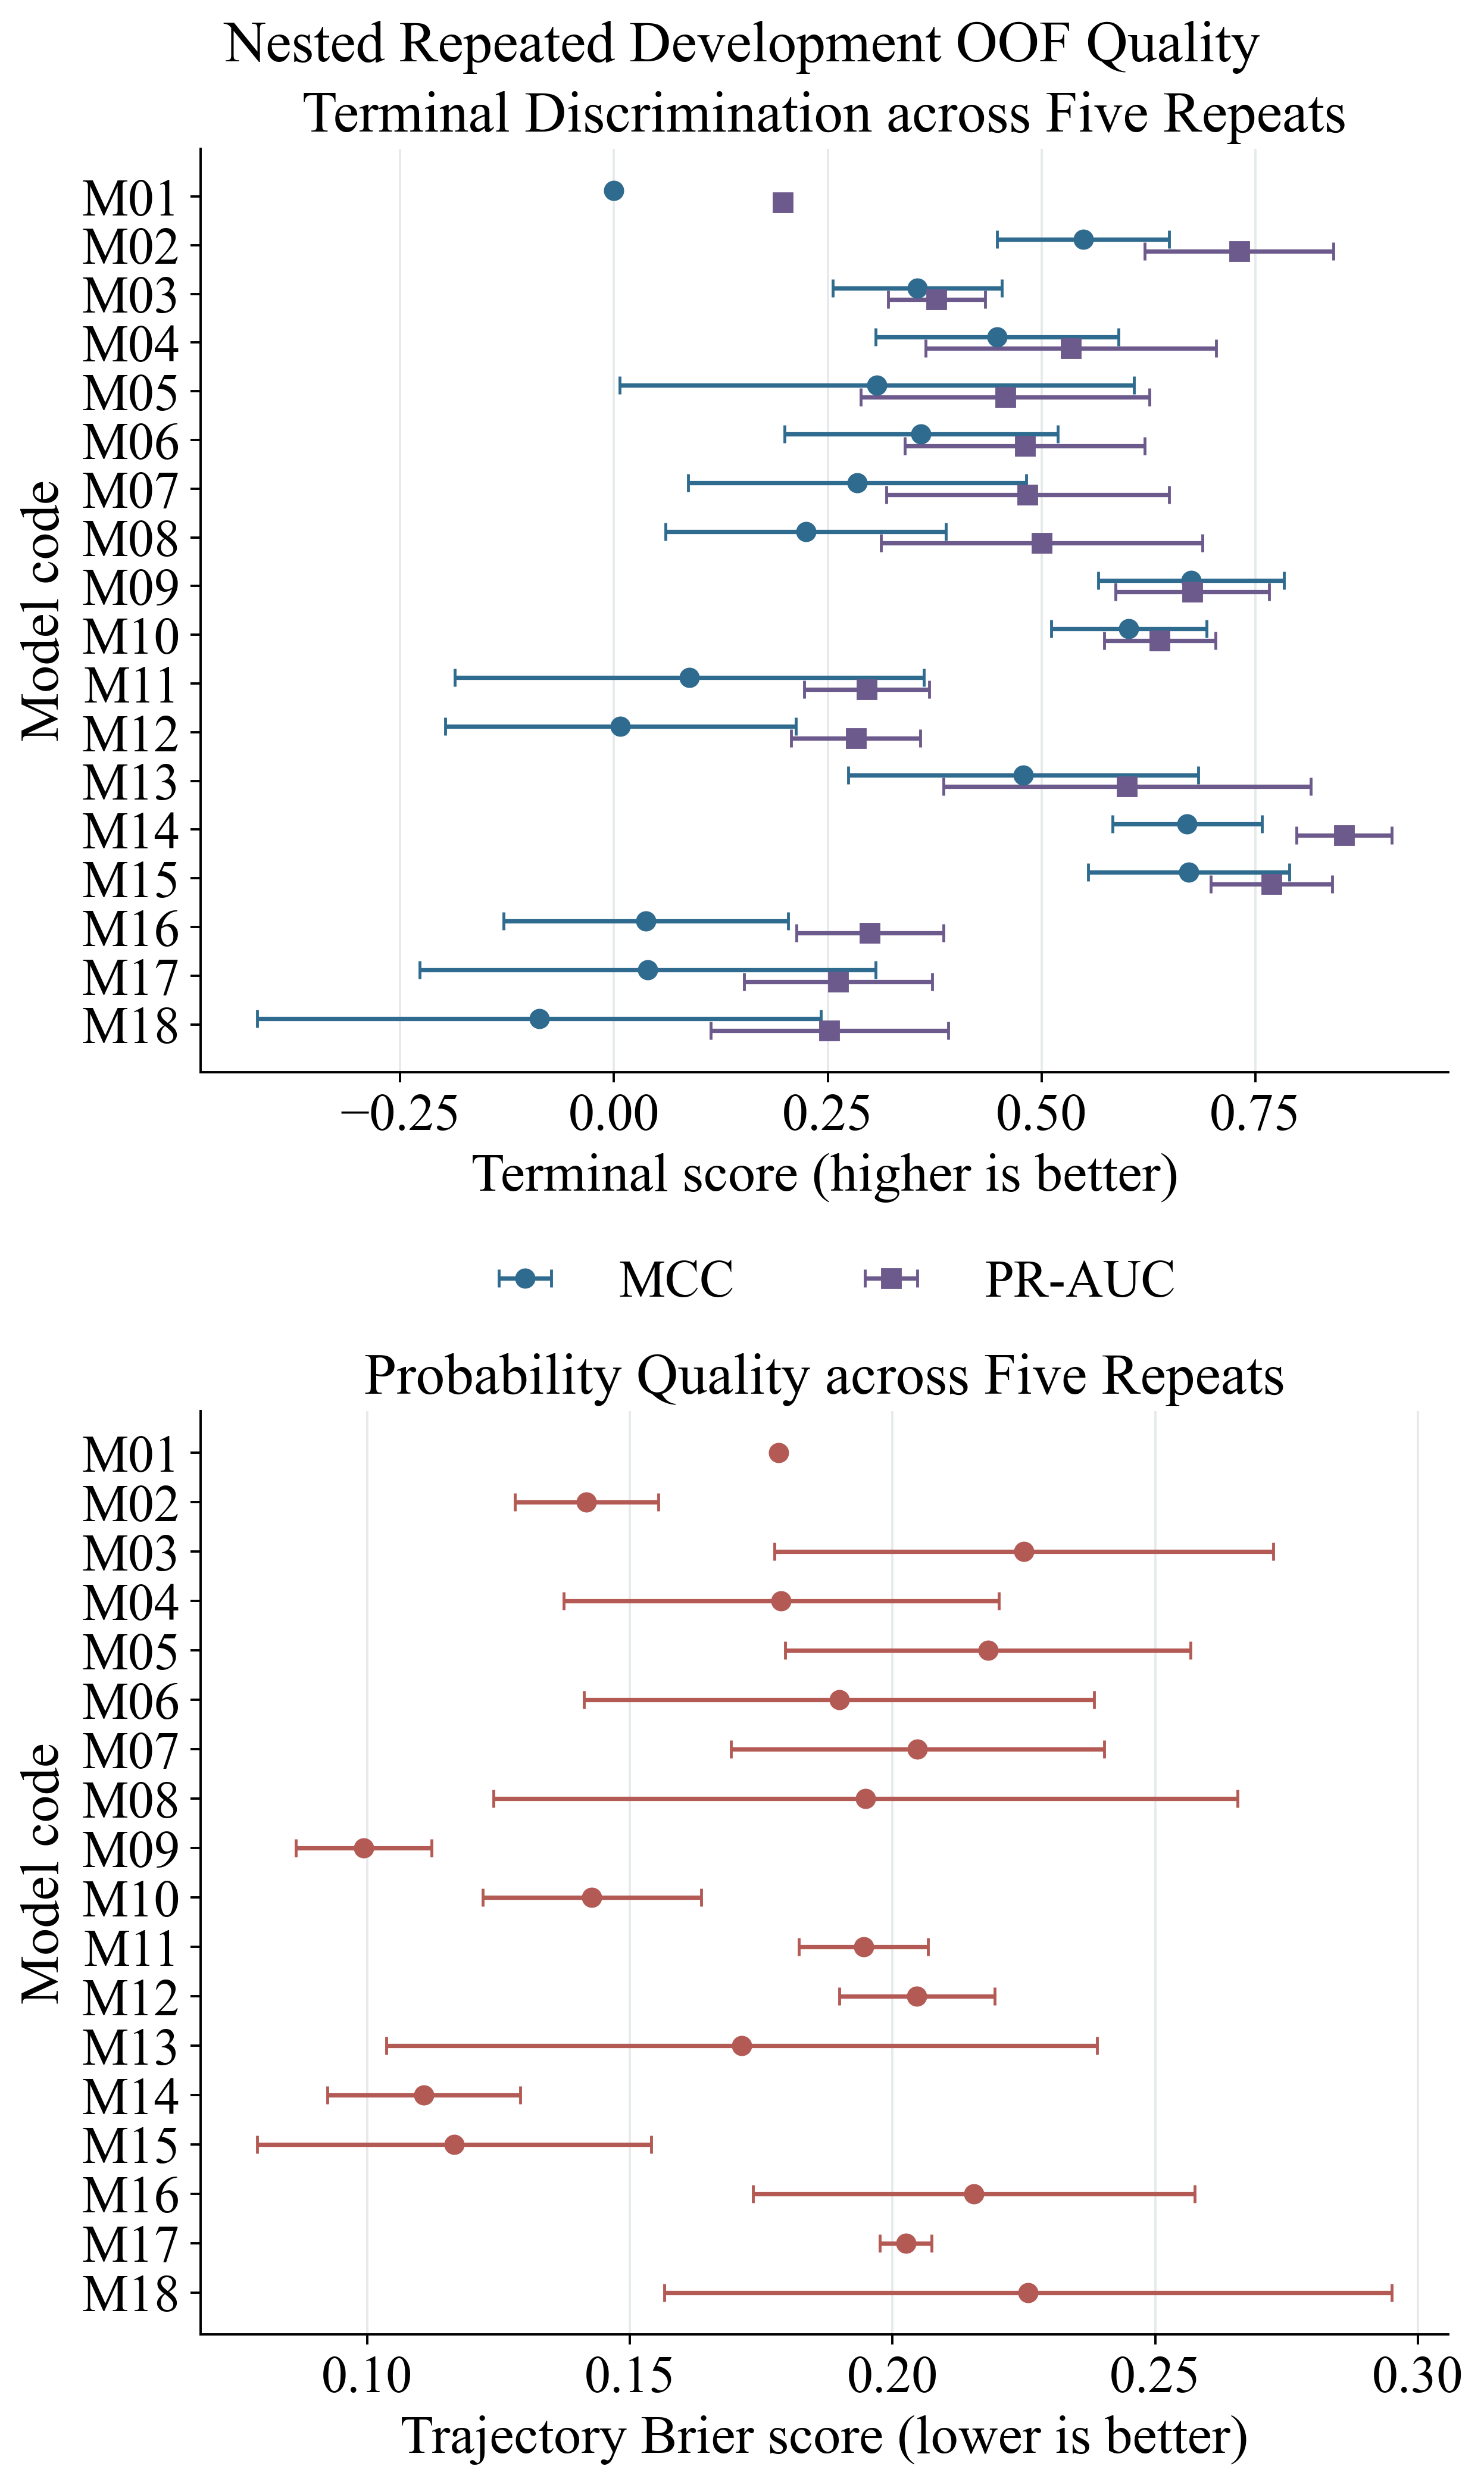

In [65]:
plot_table = oof_results.set_index("model").loc[MODEL_ORDER].reset_index()
codes = [f"M{index:02d}" for index in range(1, len(MODEL_ORDER) + 1)]
positions = np.arange(len(MODEL_ORDER))
fig, axes = figure_subplots(2, 1, span="double", square_axes=False, height_mm=300.0,
                             legend_items=2, annotation_rows=len(MODEL_ORDER))
axes[0].errorbar(plot_table["mcc_mean"], positions - .12, xerr=plot_table["mcc_sd"],
                 fmt="o", color=FIGURE_PALETTE["baseline"], capsize=3, label="MCC")
axes[0].errorbar(plot_table["pr_auc_mean"], positions + .12, xerr=plot_table["pr_auc_sd"],
                 fmt="s", color=FIGURE_PALETTE["sota"], capsize=3, label="PR-AUC")
axes[0].set_yticks(positions, codes); axes[0].set_xlabel("Terminal score (higher is better)")
axes[0].set_ylabel("Model code"); axes[0].set_title("Terminal Discrimination across Five Repeats")
axes[0].grid(axis="x", color=FIGURE_PALETTE["grid"]); axes[0].invert_yaxis(); legend_below(axes[0], 2)
axes[1].errorbar(plot_table["brier_mean"], positions, xerr=plot_table["brier_sd"],
                 fmt="o", color=FIGURE_PALETTE["error"], capsize=3)
axes[1].set_yticks(positions, codes); axes[1].set_xlabel("Trajectory Brier score (lower is better)")
axes[1].set_ylabel("Model code"); axes[1].set_title("Probability Quality across Five Repeats")
axes[1].grid(axis="x", color=FIGURE_PALETTE["grid"]); axes[1].invert_yaxis()
fig.suptitle("Nested Repeated Development OOF Quality")
register_figure_contract(fig, "03_oof_quality.png", nrows=2, ncols=1,
                         axis_units_complete=True)
_ = save_show_figure(fig, FIGURES / "03_oof_quality.png", span="double")


The vertical two-panel canvas separates terminal discrimination from trajectory probability quality; uncertainty bars are the SD across five experiment-partition repeats.


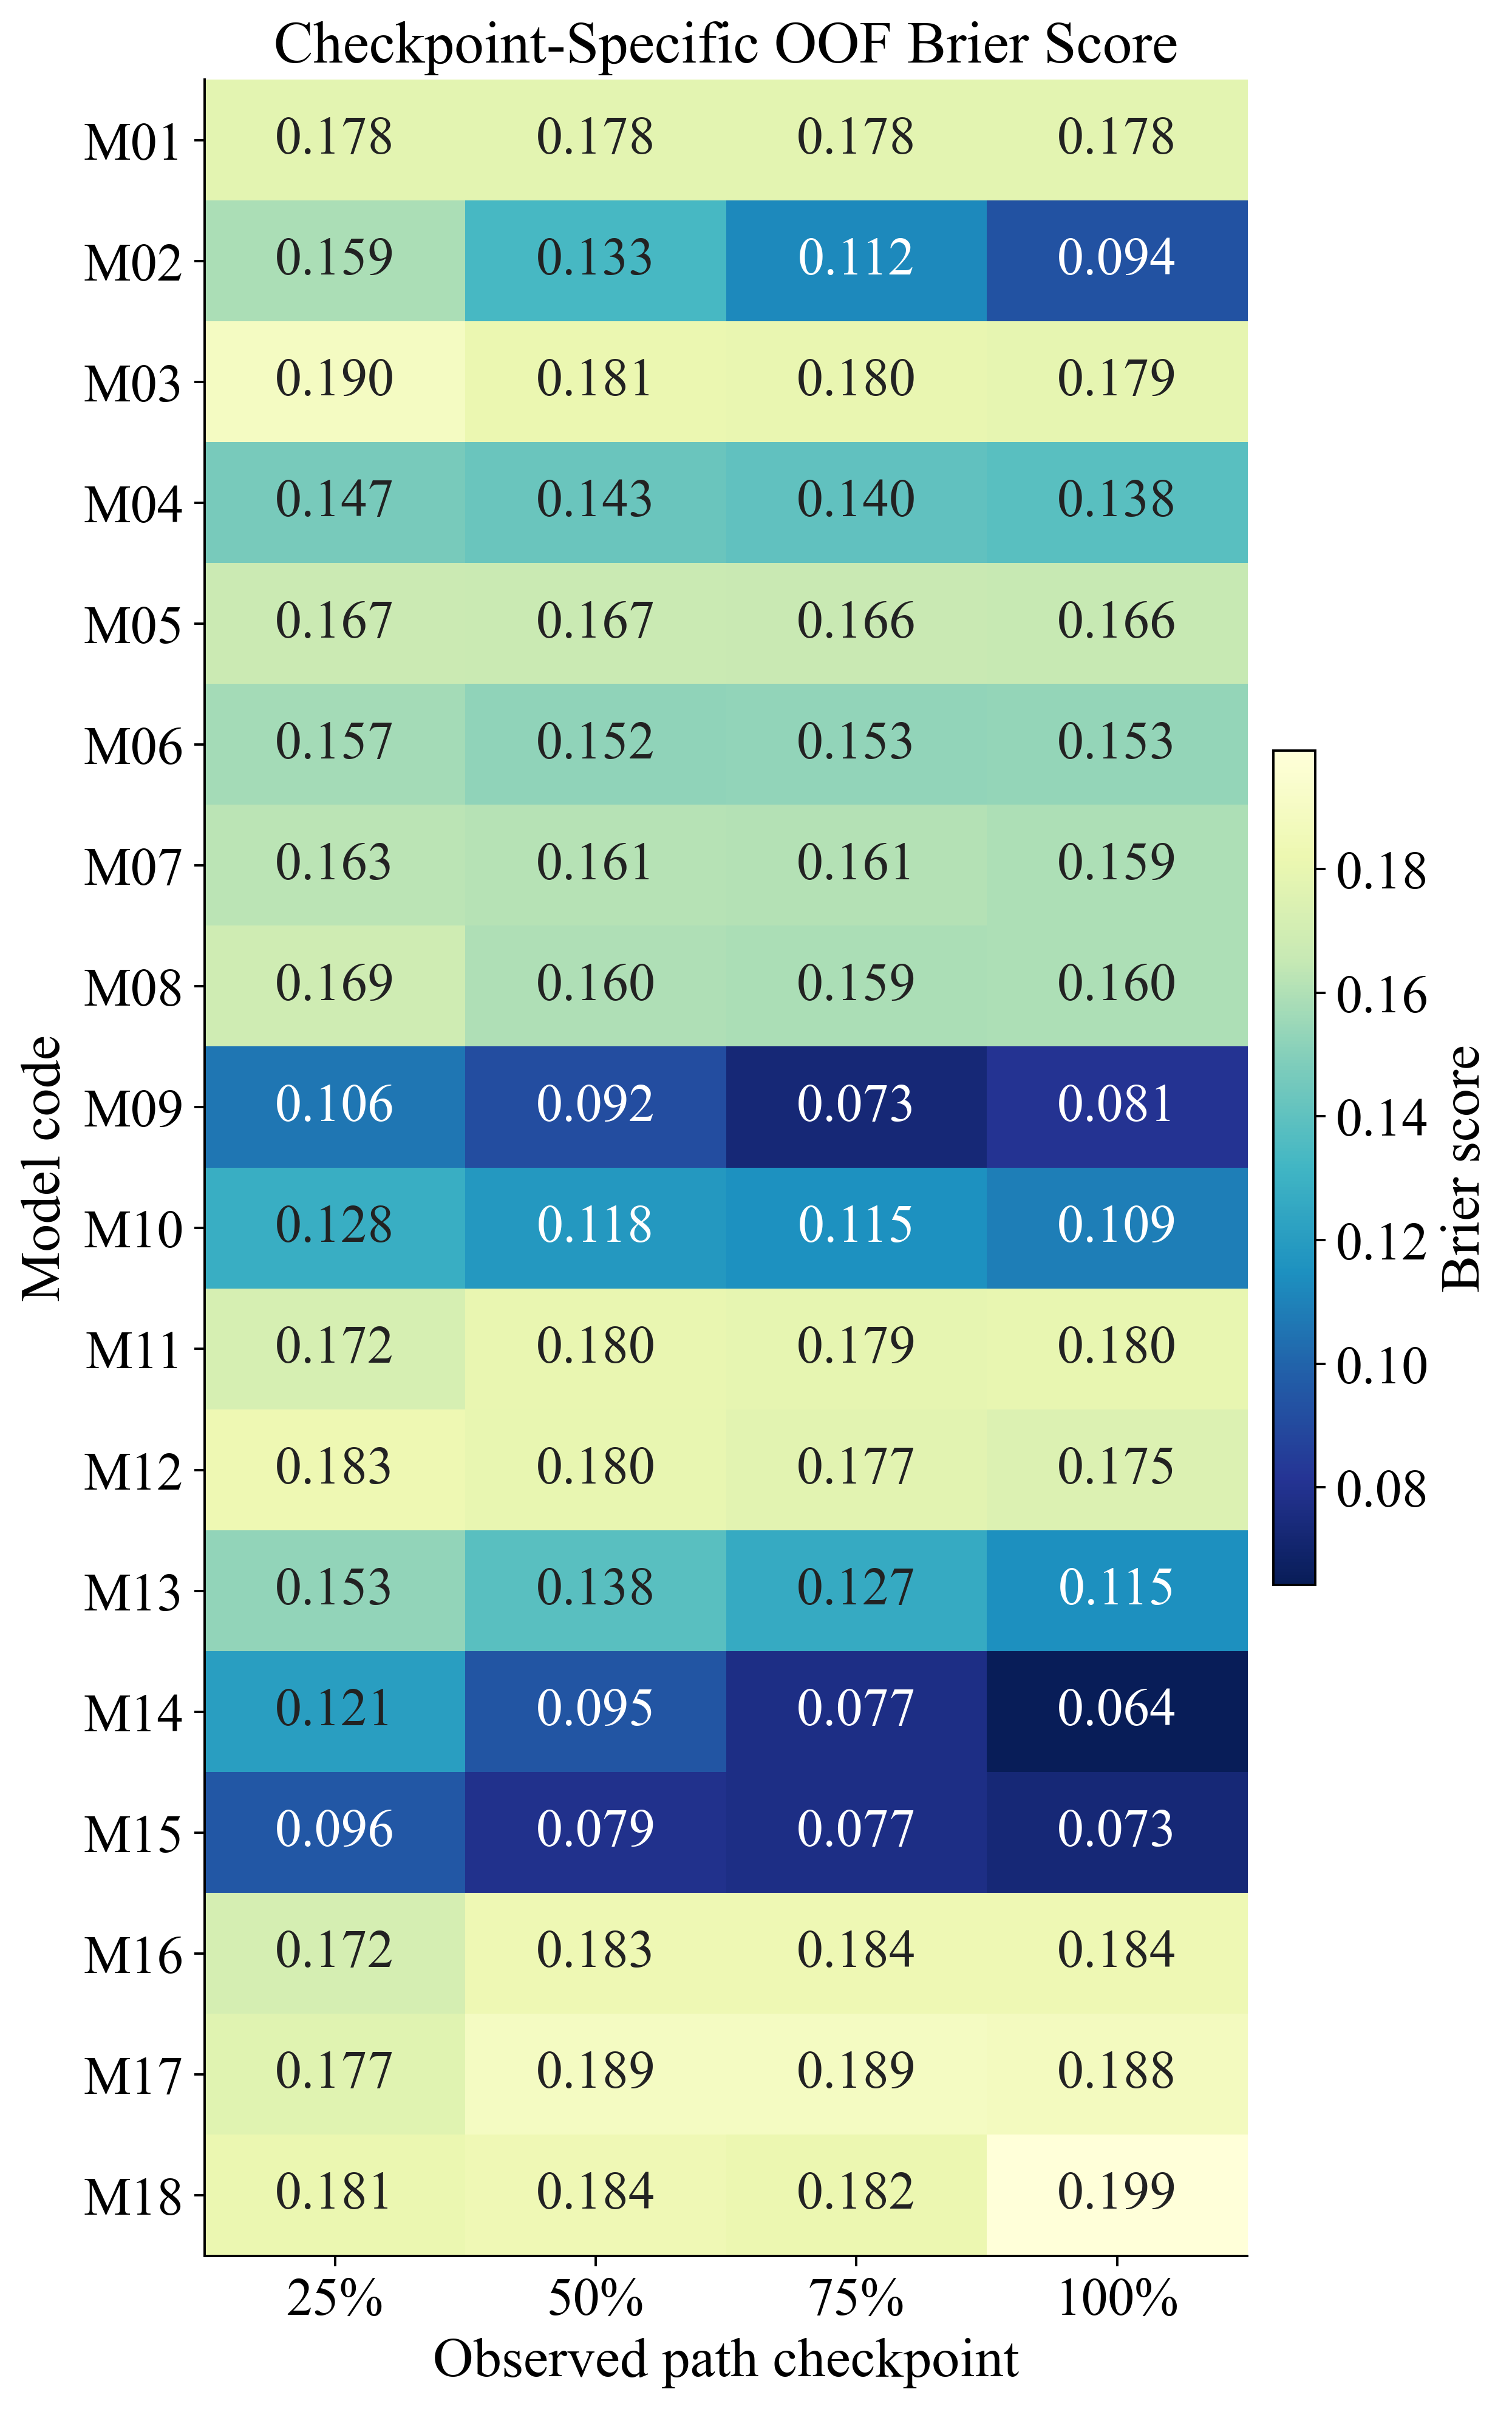

In [66]:
checkpoint_rows = []
for name in MODEL_ORDER:
    local = oof_predictions[oof_predictions["model"].eq(name)]
    for checkpoint, frame in local.groupby("checkpoint", sort=True):
        checkpoint_rows.append({"model": name, "checkpoint": checkpoint,
                                "brier": brier_score_loss(frame["target"], frame["oof_probability"])})
checkpoint_table = pd.DataFrame(checkpoint_rows)
matrix = checkpoint_table.pivot(index="model", columns="checkpoint", values="brier").loc[MODEL_ORDER]
fig, ax = figure_subplots(1, 1, span="double", height_mm=285.0,
                           labels=MODEL_ORDER, annotation_rows=len(MODEL_ORDER))
image = ax.imshow(matrix.to_numpy(), cmap=mpl.colormaps["YlGnBu_r"], aspect="auto")
ax.set_xticks(np.arange(4), ["25%", "50%", "75%", "100%"])
ax.set_yticks(np.arange(len(MODEL_ORDER)), [f"M{i:02d}" for i in range(1, len(MODEL_ORDER) + 1)])
ax.set_xlabel("Observed path checkpoint"); ax.set_ylabel("Model code")
ax.set_title("Checkpoint-Specific OOF Brier Score")
colorbar = fig.colorbar(image, ax=ax, fraction=.04, pad=.025); colorbar.set_label("Brier score")
annotate_heatmap_values(image, digits=3)
register_figure_contract(fig, "03_checkpoint_quality.png", nrows=1, ncols=1,
                         axis_units_complete=True)
_ = save_show_figure(fig, FIGURES / "03_checkpoint_quality.png", span="double")

The matrix exposes when probability quality emerges along the observed path. Zero and missing values are not conflated, and annotation contrast follows cell luminance.


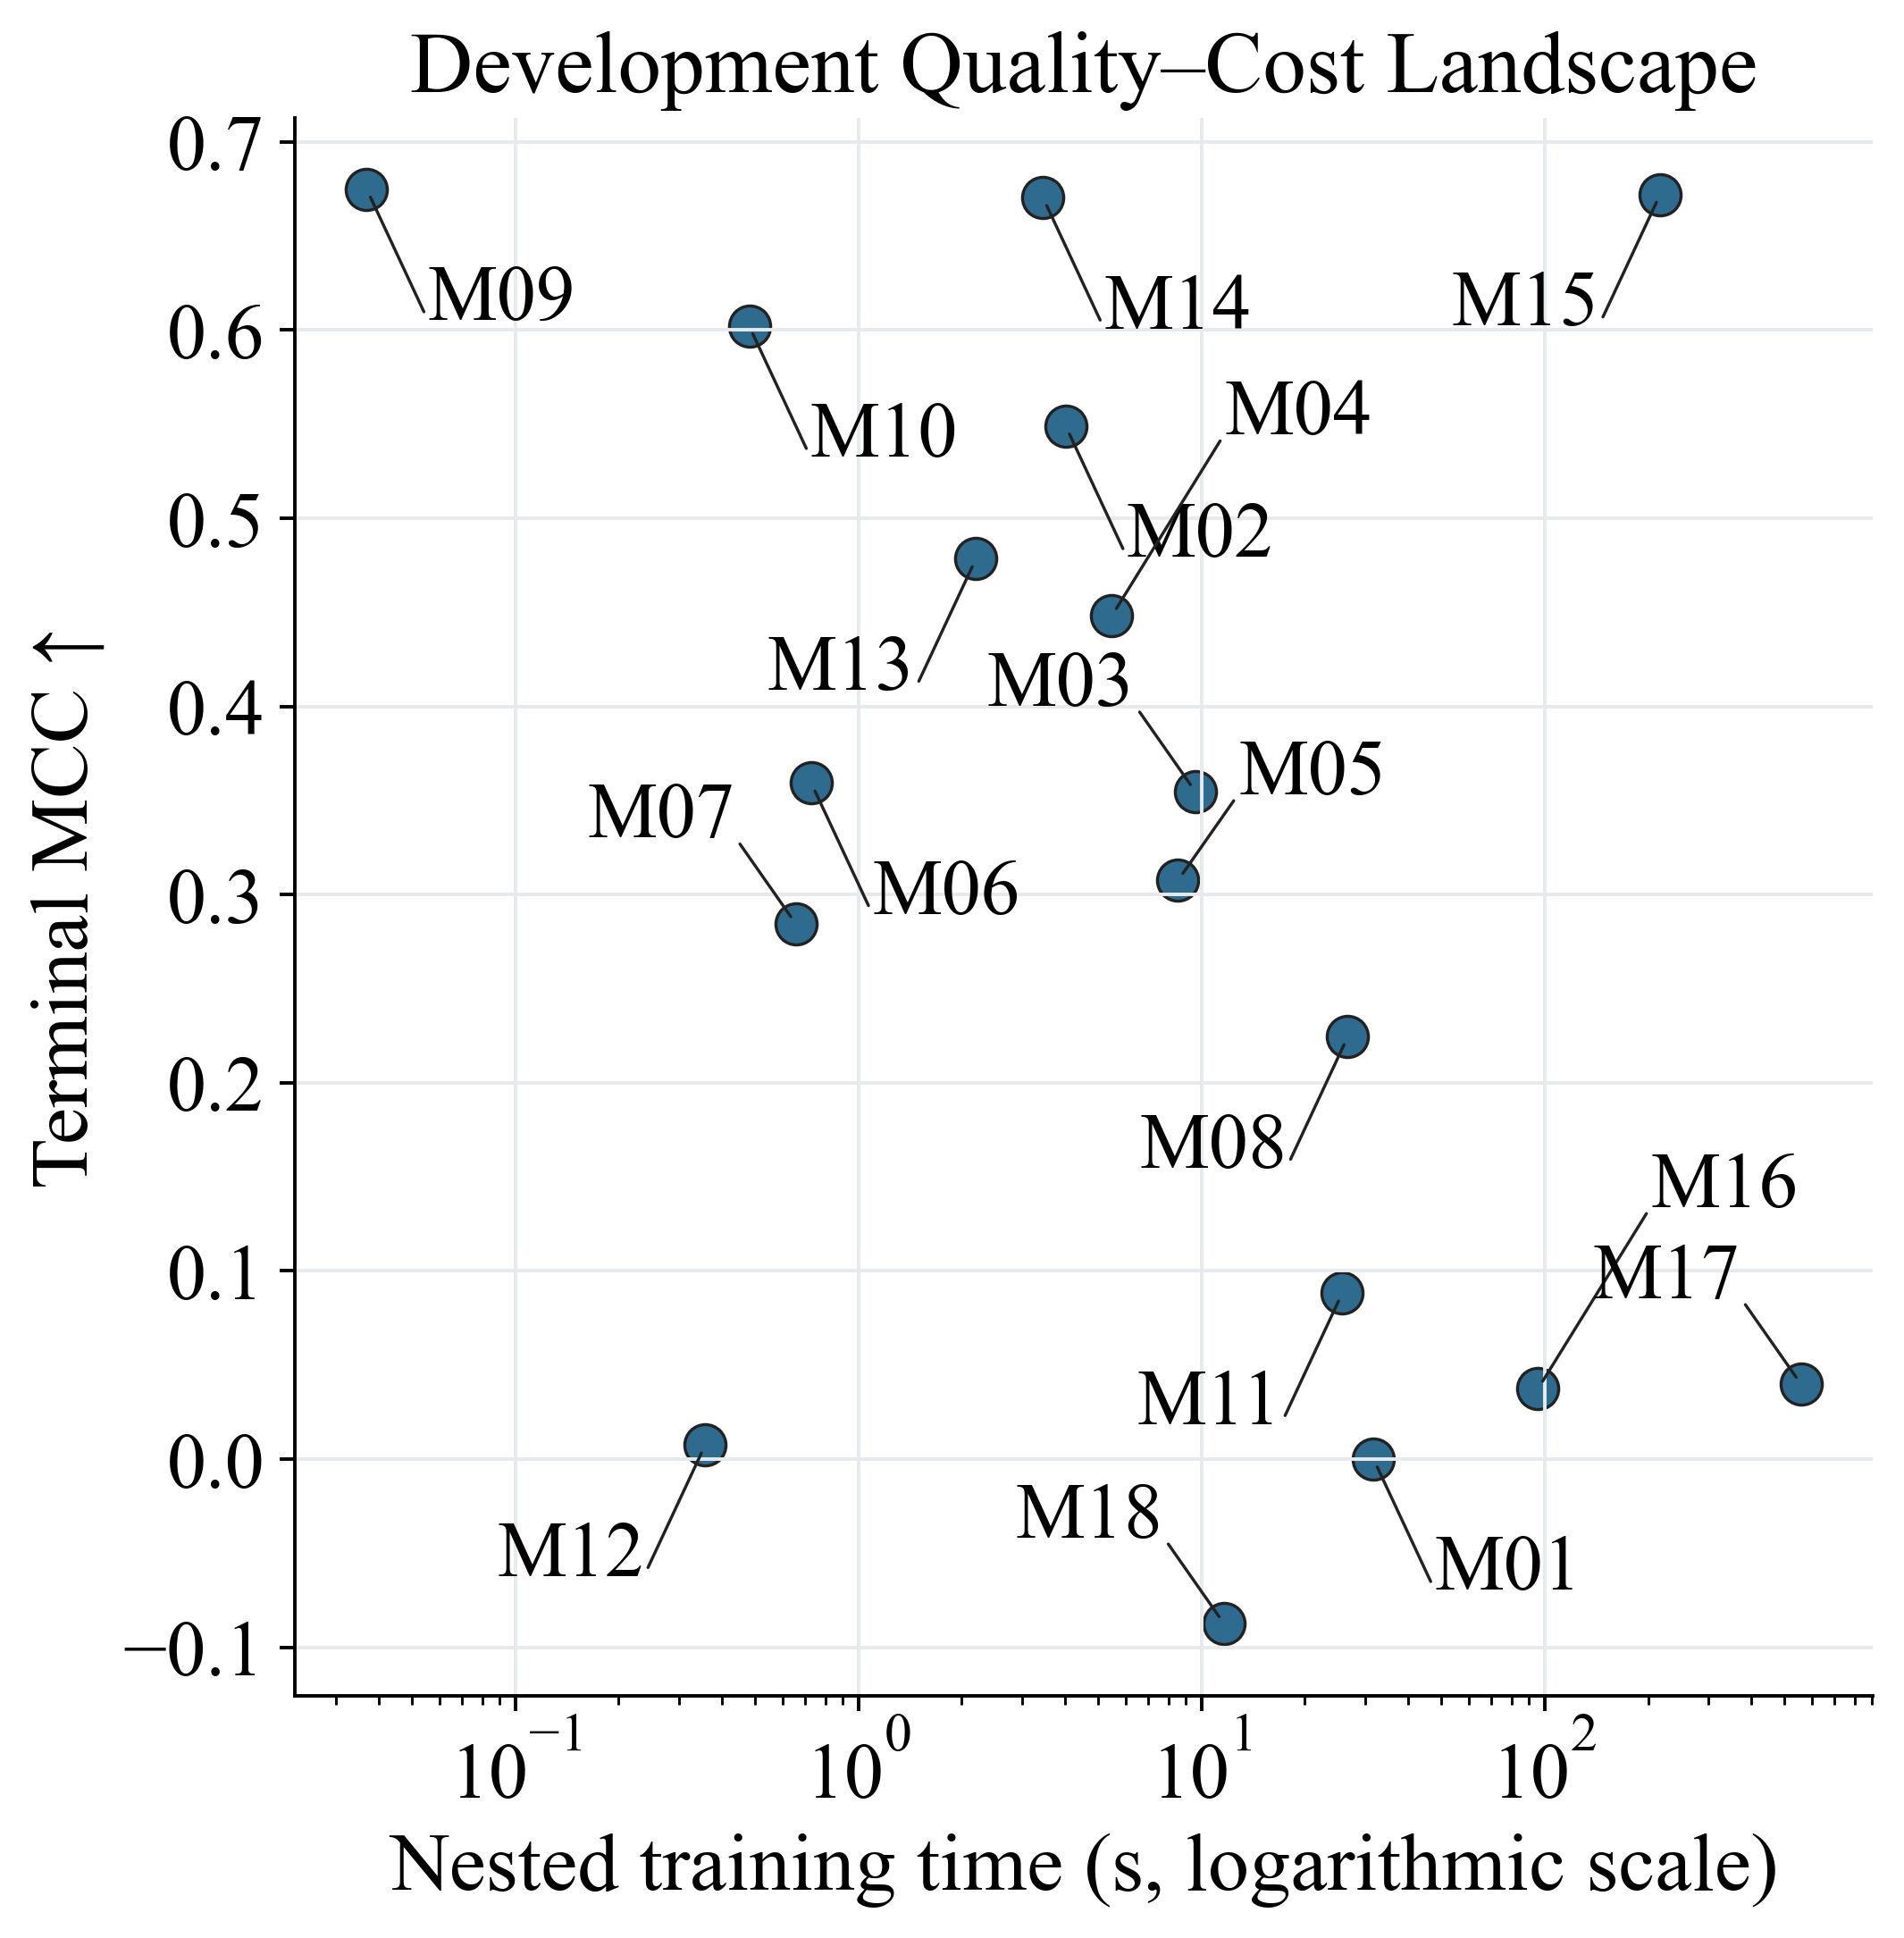

In [67]:
pareto = plot_table.merge(runtime, on="model", how="left")
fig, ax = figure_subplots(1, 1, span="double", square_panel=True, height_mm=178.0,
                           labels=MODEL_ORDER, annotation_rows=len(MODEL_ORDER))
fig.set_layout_engine(None); fig.subplots_adjust(left=.20, right=.97, bottom=.18, top=.90)
ax.scatter(pareto["nested_train_time_s"], pareto["mcc_mean"], s=90,
           color=FIGURE_PALETTE["baseline"], edgecolor=FIGURE_PALETTE["black"], linewidth=.7)
ax.set_xscale("log"); ax.set_xlabel("Nested training time (s, logarithmic scale)")
ax.set_ylabel("Terminal MCC ↑")
ax.set_title("Development Quality–Cost Landscape")
ax.grid(color=FIGURE_PALETTE["grid"]); fig.canvas.draw()
point_pixels = ax.transData.transform(pareto[["nested_train_time_s", "mcc_mean"]])
point_boxes = [mpl.transforms.Bbox.from_bounds(x - 28, y - 28, 56, 56)
               for x, y in point_pixels]
offset_candidates = [(14, 20), (14, -30), (-14, 20), (-14, -30),
                     (26, 42), (26, -52), (-26, 42), (-26, -52),
                     (42, 66), (42, -76), (-42, 66), (-42, -76)]
label_artists, label_boxes = [], []
for index, row in pareto.iterrows():
    selected_artist = None
    candidates = offset_candidates[index % 4:] + offset_candidates[:index % 4]
    for horizontal, vertical in candidates:
        artist = ax.annotate(f"M{index + 1:02d}",
                             (row["nested_train_time_s"], row["mcc_mean"]),
                             xytext=(horizontal, vertical), textcoords="offset points",
                             fontsize=FONT_SIZE, ha="left" if horizontal > 0 else "right")
        fig.canvas.draw(); renderer = fig.canvas.get_renderer()
        candidate_box = artist.get_window_extent(renderer).expanded(1.04, 1.10)
        clear = not any(candidate_box.overlaps(box) for box in label_boxes + point_boxes)
        inside = ax.bbox.contains(*candidate_box.p0) and ax.bbox.contains(*candidate_box.p1)
        if clear and inside:
            selected_artist = artist; label_boxes.append(candidate_box); break
        artist.remove()
    assert selected_artist is not None; label_artists.append(selected_artist)
    ax.annotate("", (row["nested_train_time_s"], row["mcc_mean"]),
                xytext=selected_artist.get_position(), textcoords="offset points",
                arrowprops={"arrowstyle": "-", "color": FIGURE_PALETTE["black"], "lw": .7})
fig.canvas.draw(); overlap_free = not text_boxes_overlap(fig, label_artists)
register_figure_contract(fig, "03_efficiency_pareto.png", nrows=1, ncols=1,
                         axis_units_complete=True, structural_overlap_free=overlap_free)
_ = save_show_figure(fig, FIGURES / "03_efficiency_pareto.png", span="double")

The cost axis is logarithmic. The canvas is descriptive: Pareto non-domination is assessed later together with statistical uncertainty.


In [68]:
model_key = pd.DataFrame({"code": [f"M{index:02d}" for index in range(1, len(MODEL_ORDER) + 1)],
                          "model": MODEL_ORDER})
display_grouped_tables(model_key, ["code"], {"Model identity": ["model"]}, digits=4)

#### Model identity

,code,model
0,M01,Dummy — Empirical Prior
1,M02,Elastic-Net Logistic Regression
2,M03,Random Forest
3,M04,Extra Trees
4,M05,HistGradientBoosting
5,M06,XGBoost
6,M07,LightGBM
7,M08,CatBoost
8,M09,Gaussian Naive Bayes
9,M10,Quantile Naive Bayes


Model codes provide a complete, non-truncated key for all three comparison figures.


In [69]:
tuning_budget.to_csv(TABLES / "model03_tuning_budget.csv", index=False)
tuning_results.to_csv(TABLES / "model03_tuning_results.csv", index=False)
outer_selected.to_csv(TABLES / "model03_outer_selected_configurations.csv", index=False)
frozen_configuration.to_csv(TABLES / "model03_selected_configurations.csv", index=False)
oof_results.to_csv(TABLES / "model03_oof_results.csv", index=False)
fold_seed_metrics.to_csv(TABLES / "model03_fold_seed_metrics.csv", index=False)
calibration_results.to_csv(TABLES / "model03_calibration_results.csv", index=False)
runtime.to_csv(TABLES / "model03_runtime.csv", index=False)
model_key.to_csv(TABLES / "model03_model_key.csv", index=False)
seed_oof.to_parquet(PROJECT_ROOT / "dataset" / "predictions" / "model03_seed_oof_predictions.parquet", index=False)
oof_predictions.to_parquet(PROJECT_ROOT / "dataset" / "predictions" / "model03_oof_predictions.parquet", index=False)
validation_predictions.to_parquet(PROJECT_ROOT / "dataset" / "predictions" / "model03_validation_predictions.parquet", index=False)
locked_predictions.to_parquet(PROJECT_ROOT / "dataset" / "predictions" / "model03_locked_predictions.parquet", index=False)


## Summary

Notebook 03 supplies nested repeated development OOF evidence for 18 matched model families, together with frozen configurations and outcome-free validation/locked probability ledgers. It does not claim superiority from these development results. Discriminative-parent selection in Notebook 04 uses development OOF results, with validation, internal and external outcomes excluded.
